# Setup and configuration

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [296]:
RANDOM_SEED = 42

ROOT_DIR = Path.cwd()
STAGE2_OUTPUT_DIR = ROOT_DIR / "outputs" / "stage2"
STAGE3_OUTPUT_DIR = ROOT_DIR / "outputs" / "stage3"

STAGE3_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_SEED)

N_BOOTSTRAP = 1000

# Load Stage 2 outputs

In [3]:
# Stage 2 output files
trade_features_path = STAGE2_OUTPUT_DIR / "trade_features.parquet"
idea_features_path = STAGE2_OUTPUT_DIR / "idea_features.parquet"
feature_check_results_path = STAGE2_OUTPUT_DIR / "feature_check_results.csv"
feature_dictionary_path = STAGE2_OUTPUT_DIR / "feature_dictionary.csv"

# Load Stage 2 outputs
trade_features = pd.read_parquet(trade_features_path)
idea_features = pd.read_parquet(idea_features_path)
feature_check_results = pd.read_csv(feature_check_results_path)
feature_dictionary = pd.read_csv(feature_dictionary_path)

In [4]:
print(f"trade_features shape: {trade_features.shape}")
print(f"idea_features shape: {idea_features.shape}")
print(f"feature_check_results shape: {feature_check_results.shape}")
print(f"feature_dictionary shape: {feature_dictionary.shape}")

trade_features shape: (46520, 131)
idea_features shape: (33379, 44)
feature_check_results shape: (23, 12)
feature_dictionary shape: (24, 8)


In [5]:
trade_model_data = trade_features.copy()
idea_model_data = idea_features.copy()

In [6]:
idea_timing_columns = [
    "idea_id",
    "minutes_since_previous_idea_start",
    "past_median_idea_start_gap_minutes",
    "idea_start_gap_to_past_median_ratio",
]

trade_model_data = trade_model_data.merge(
    idea_features[idea_timing_columns],
    on="idea_id",
    how="left",
    validate="many_to_one",
)

# Prepare leakage-safe features

## Define identifier, target and banned features

In [7]:
# Columns needed for splitting, evaluation, and account-level bootstrap.
identifier_columns = [
    "trade_row_id",
    "campaign_id",
    "account_id",
    "idea_id",
    "open_date_time",
    "close_date_time",
]

evaluation_columns = [
    "amount", 
    "reverse_profit",
]

target_column = "reverse_profit_per_lot"

In [8]:
banned_sl_tp_columns = [
    "sl_price",
    "tp_price",
    "has_stop_loss",
    "has_take_profit",
    "has_both_sl_tp",
    "has_neither_sl_tp",
    "sl_tp_configuration",
    "stop_loss_distance",
    "take_profit_distance",
    "valid_stop_loss_distance",
    "valid_take_profit_distance",
    "stop_loss_distance_pct",
    "take_profit_distance_pct",
    "planned_reward_to_risk_ratio",
]

In [9]:
banned_outcome_columns = [
    "profit",
    "net_profit",
    "reverse_profit",
    "expected_net_profit",
    "net_profit_difference",
    "net_profit_reconciles",
    "reverse_profit_per_lot",
    "idea_end_time",
    "mean_net_profit",
    "maximum_net_profit",
    "minimum_net_profit",
    "total_net_profit",
]

## Define leakage-safe stage 2 candidate features

### Loss response

In [10]:
loss_response_features = [
    "post_loss_entry",
    "post_loss_reentry_gap_minutes",
    "post_loss_amount_ratio",
    "post_loss_amount_increased",
]

### Trading activity and timing

In [11]:
activity_timing_features = [
    "past_trade_open_count",
    "past_idea_start_count",
    "elapsed_active_minutes",
    "elapsed_active_hours",
    "past_trades_opened_per_active_hour",
    "past_ideas_started_per_active_hour",
    "trades_opened_past_15_minutes",
    "trades_opened_past_30_minutes",
    "trades_opened_past_60_minutes",
    "ideas_started_past_15_minutes",
    "ideas_started_past_30_minutes",
    "ideas_started_past_60_minutes",
    "minutes_since_previous_trade_open",
    "past_median_trade_open_gap_minutes",
    "trade_open_gap_to_past_median_ratio",
    "minutes_since_previous_idea_start",
    "past_median_idea_start_gap_minutes",
    "idea_start_gap_to_past_median_ratio",
]

### Challenge state and drawdown pressure

In [12]:
challenge_state_features = [
    "realized_pnl_before_trade",
    "realized_return_before_trade",
    "realized_balance_before_trade",
    "realized_distance_to_drawdown_limit",
    "realized_distance_to_profit_target",
]

### Position sizing

In [13]:
position_sizing_features = [
    "historical_median_amount_before_trade",
    "current_to_historical_median_amount_ratio",
    "past_amount_count",
    "past_amount_mean",
    "past_amount_std",
    "past_amount_cv",
]

### Historical performance

In [14]:
historical_performance_features = [
    "past_completed_idea_count",
    "past_winning_idea_count",
    "past_losing_idea_count",
    "past_idea_win_rate",
    "past_mean_win_profit_per_lot",
    "past_mean_loss_abs_profit_per_lot",
    "past_payoff_ratio",
]

In [15]:
candidate_feature_columns = (
    loss_response_features
    + activity_timing_features
    + challenge_state_features
    + position_sizing_features
    + historical_performance_features
)

## Keep only features that actually exist

In [16]:
available_feature_columns = [
    column
    for column in candidate_feature_columns
    if column in trade_model_data.columns
]

missing_feature_columns = sorted(
    set(candidate_feature_columns) - set(available_feature_columns)
)

print(f"Candidate features requested: {len(candidate_feature_columns)}")
print(f"Candidate features available: {len(available_feature_columns)}")

if missing_feature_columns:
    print("\nMissing Stage 2 features:")
    for column in missing_feature_columns:
        print(f"- {column}")

Candidate features requested: 40
Candidate features available: 40


## Leakage assertion

In [17]:
banned_feature_columns = set(
    banned_sl_tp_columns
    + banned_outcome_columns
)

leaking_features = sorted(
    set(available_feature_columns) & banned_feature_columns
)

assert not leaking_features, (
    "Leakage detected in model features: "
    + ", ".join(leaking_features)
)

print("Leakage check passed.")

Leakage check passed.


# Rebuild SL/TP behaviour using only pre-trade information

## Predicted  SL/TP probability

### Build historical SL/TP usage features

In [18]:
def build_historical_sl_tp_usage_features(data):
    """Build account-level historical SL/TP usage features.

    For each trade, only trades from the same account that closed strictly
    before the current trade opened are included.

    Args:
        data: Trade-level DataFrame containing account ID, open and close
            timestamps, and observed SL/TP fields.

    Returns:
        DataFrame with historical SL/TP usage features attached.
    """
    result = data.copy()

    result["open_date_time"] = pd.to_datetime(result["open_date_time"])
    result["close_date_time"] = pd.to_datetime(result["close_date_time"])

    # These are historical outcomes only.
    result["observed_has_sl"] = result["sl_price"].notna().astype(int)
    result["observed_has_tp"] = result["tp_price"].notna().astype(int)

    result["observed_has_both_sl_tp"] = (
        (result["observed_has_sl"] == 1)
        & (result["observed_has_tp"] == 1)
    ).astype(int)

    result["observed_has_neither_sl_tp"] = (
        (result["observed_has_sl"] == 0)
        & (result["observed_has_tp"] == 0)
    ).astype(int)

    # Aggregate trades closing at exactly the same timestamp.
    close_events = (
        result.groupby(
            ["account_id", "close_date_time"],
            as_index=False,
        )
        .agg(
            completed_trade_count=("trade_row_id", "size"),
            completed_sl_count=("observed_has_sl", "sum"),
            completed_tp_count=("observed_has_tp", "sum"),
            completed_both_sl_tp_count=("observed_has_both_sl_tp", "sum"),
            completed_neither_sl_tp_count=(
                "observed_has_neither_sl_tp",
                "sum",
            ),
        )
    )

    cumulative_columns = [
        "completed_trade_count",
        "completed_sl_count",
        "completed_tp_count",
        "completed_both_sl_tp_count",
        "completed_neither_sl_tp_count",
    ]

    close_events = close_events.sort_values(
        ["close_date_time", "account_id"]
    )

    close_events[cumulative_columns] = (
        close_events.groupby("account_id")[cumulative_columns]
        .cumsum()
    )

    trade_order = result.sort_values(
        ["open_date_time", "account_id", "trade_row_id"]
    ).copy()

    historical = pd.merge_asof(
        trade_order[
            [
                "trade_row_id",
                "account_id",
                "open_date_time",
            ]
        ],
        close_events,
        by="account_id",
        left_on="open_date_time",
        right_on="close_date_time",
        direction="backward",
        allow_exact_matches=False,
    )

    historical = historical.rename(
        columns={
            "completed_trade_count": "past_completed_trade_count",
            "completed_sl_count": "past_sl_count",
            "completed_tp_count": "past_tp_count",
            "completed_both_sl_tp_count": "past_both_sl_tp_count",
            "completed_neither_sl_tp_count": "past_neither_sl_tp_count",
        }
    )

    count = historical["past_completed_trade_count"]

    historical["past_sl_usage_rate"] = (
        historical["past_sl_count"] / count
    )

    historical["past_tp_usage_rate"] = (
        historical["past_tp_count"] / count
    )

    historical["past_both_sl_tp_rate"] = (
        historical["past_both_sl_tp_count"] / count
    )

    historical["past_neither_sl_tp_rate"] = (
        historical["past_neither_sl_tp_count"] / count
    )

    historical_features = [
        "trade_row_id",
        "past_completed_trade_count",
        "past_sl_count",
        "past_tp_count",
        "past_both_sl_tp_count",
        "past_neither_sl_tp_count",
        "past_sl_usage_rate",
        "past_tp_usage_rate",
        "past_both_sl_tp_rate",
        "past_neither_sl_tp_rate",
    ]

    result = result.merge(
        historical[historical_features],
        on="trade_row_id",
        how="left",
        validate="one_to_one",
    )

    return result

In [19]:
trade_model_data = build_historical_sl_tp_usage_features(
    trade_model_data
)

### Walk-forward probability prediction for SL/TP

In [20]:
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def build_probability_model(model_name):
    """Build a probability classification model.

    Args:
        model_name: Name of the classification model.

    Returns:
        Classification model compatible with predict_proba().

    Raises:
        ValueError: If the requested model is unsupported.
    """
    if model_name == "logistic_regression":
        return Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    LogisticRegression(
                        max_iter=1_000,
                        random_state=RANDOM_SEED,
                    ),
                ),
            ]
        )

    if model_name == "lightgbm":
        return LGBMClassifier(
            n_estimators=200,
            learning_rate=0.05,
            num_leaves=15,
            random_state=RANDOM_SEED,
            verbosity=-1,
        )

    if model_name == "xgboost":
        return XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=RANDOM_SEED,
            eval_metric="logloss",
            n_jobs=-1,
        )

    if model_name == "catboost":
        return CatBoostClassifier(
            iterations=200,
            learning_rate=0.05,
            depth=6,
            random_seed=RANDOM_SEED,
            verbose=False,
        )

    raise ValueError(
        f"Unsupported model_name: {model_name}"
    )

In [21]:
def walk_forward_probability_model(
    data,
    feature_columns,
    target_column,
    model_name,
    campaign_column="campaign_id",
    minimum_training_campaigns=10,
):
    """Generate expanding-window walk-forward probability predictions.

    For each test campaign, the model is trained on all strictly earlier
    campaigns and then used to predict the current campaign.

    Args:
        data: Trade-level DataFrame.
        feature_columns: Pre-trade predictor columns.
        target_column: Binary target column.
        model_name: Classification model to use.
        campaign_column: Campaign identifier column.
        minimum_training_campaigns: Minimum number of earlier campaigns
            required before prediction begins.

    Returns:
        DataFrame containing out-of-sample predictions.
    """
    campaign_order = sorted(
        data[campaign_column].dropna().unique()
    )

    prediction_records = []

    for campaign_index, test_campaign in enumerate(campaign_order):
        training_campaigns = campaign_order[:campaign_index]

        if len(training_campaigns) < minimum_training_campaigns:
            continue

        train = data.loc[
            data[campaign_column].isin(training_campaigns)
        ].copy()

        test = data.loc[
            data[campaign_column] == test_campaign
        ].copy()

        X_train = train[feature_columns]
        y_train = train[target_column]

        X_test = test[feature_columns]
        y_test = test[target_column]

        if y_train.nunique() < 2:
            continue

        model = build_probability_model(model_name)

        model.fit(
            X_train,
            y_train,
        )

        predicted_probability = (
            model.predict_proba(X_test)[:, 1]
        )

        campaign_predictions = test[
            [
                "trade_row_id",
                "account_id",
                campaign_column,
            ]
        ].copy()

        campaign_predictions["observed_target"] = (
            y_test.to_numpy()
        )

        campaign_predictions["predicted_probability"] = (
            predicted_probability
        )

        campaign_predictions["model_name"] = model_name

        prediction_records.append(
            campaign_predictions
        )

    if not prediction_records:
        return pd.DataFrame()

    return pd.concat(
        prediction_records,
        ignore_index=True,
    )

In [22]:
historical_sl_tp_features = [
    "past_completed_trade_count",
    "past_sl_usage_rate",
    "past_tp_usage_rate",
    "past_both_sl_tp_rate",
    "past_neither_sl_tp_rate",
]

sl_tp_probability_features = (
    available_feature_columns
    + historical_sl_tp_features
)

In [23]:
development_data = trade_model_data.loc[
    trade_model_data["campaign_id"] <= 52
].copy()

In [24]:
sl_logistic_predictions = walk_forward_probability_model(
    data=development_data,
    feature_columns=sl_tp_probability_features,
    target_column="observed_has_sl",
    model_name="logistic_regression",
    minimum_training_campaigns=10,
)

sl_lightgbm_predictions = walk_forward_probability_model(
    data=development_data,
    feature_columns=sl_tp_probability_features,
    target_column="observed_has_sl",
    model_name="lightgbm",
    minimum_training_campaigns=10,
)

sl_xgboost_predictions = walk_forward_probability_model(
    data=development_data,
    feature_columns=sl_tp_probability_features,
    target_column="observed_has_sl",
    model_name="xgboost",
    minimum_training_campaigns=10,
)

sl_catboost_predictions = walk_forward_probability_model(
    data=development_data,
    feature_columns=sl_tp_probability_features,
    target_column="observed_has_sl",
    model_name="catboost",
    minimum_training_campaigns=10,
)

In [25]:
tp_logistic_predictions = walk_forward_probability_model(
    data=development_data,
    feature_columns=sl_tp_probability_features,
    target_column="observed_has_tp",
    model_name="logistic_regression",
    minimum_training_campaigns=10,
)

tp_lightgbm_predictions = walk_forward_probability_model(
    data=development_data,
    feature_columns=sl_tp_probability_features,
    target_column="observed_has_tp",
    model_name="lightgbm",
    minimum_training_campaigns=10,
)

tp_xgboost_predictions = walk_forward_probability_model(
    data=development_data,
    feature_columns=sl_tp_probability_features,
    target_column="observed_has_tp",
    model_name="xgboost",
    minimum_training_campaigns=10,
)

tp_catboost_predictions = walk_forward_probability_model(
    data=development_data,
    feature_columns=sl_tp_probability_features,
    target_column="observed_has_tp",
    model_name="catboost",
    minimum_training_campaigns=10,
)

In [26]:
def evaluate_probability_predictions(predictions):
    """Evaluate binary probability predictions.

    Args:
        predictions: DataFrame containing observed_target and
            predicted_probability columns.

    Returns:
        Dictionary of classification metrics.
    """
    y_true = predictions["observed_target"]
    y_probability = predictions["predicted_probability"]

    y_predicted = (y_probability >= 0.5).astype(int)

    metrics = {
        "n_predictions": len(predictions),
        "positive_rate": y_true.mean(),
        "accuracy": accuracy_score(
            y_true,
            y_predicted,
        ),
        "roc_auc": roc_auc_score(
            y_true,
            y_probability,
        ),
        "log_loss": log_loss(
            y_true,
            y_probability,
        ),
    }

    return metrics

In [27]:
prediction_sets = {
    ("SL", "Logistic Regression"): sl_logistic_predictions,
    ("SL", "LightGBM"): sl_lightgbm_predictions,
    ("SL", "XGBoost"): sl_xgboost_predictions,
    ("SL", "CatBoost"): sl_catboost_predictions,
    ("TP", "Logistic Regression"): tp_logistic_predictions,
    ("TP", "LightGBM"): tp_lightgbm_predictions,
    ("TP", "XGBoost"): tp_xgboost_predictions,
    ("TP", "CatBoost"): tp_catboost_predictions,
}

comparison_records = []

for (target, model_name), predictions in prediction_sets.items():
    metrics = evaluate_probability_predictions(
        predictions
    )

    comparison_records.append(
        {
            "target": target,
            "model": model_name,
            **metrics,
        }
    )

probability_model_comparison = pd.DataFrame(
    comparison_records
)

probability_model_comparison

,target,model,n_predictions,positive_rate,accuracy,roc_auc,log_loss
0,SL,Logistic Regression,12771,0.473808,0.621721,0.665003,0.651903
1,SL,LightGBM,12771,0.473808,0.647091,0.711267,0.618137
2,SL,XGBoost,12771,0.473808,0.645447,0.711145,0.617228
3,SL,CatBoost,12771,0.473808,0.648501,0.713296,0.615311
4,TP,Logistic Regression,12771,0.565813,0.631431,0.665427,0.638787
5,TP,LightGBM,12771,0.565813,0.652102,0.695569,0.617989
6,TP,XGBoost,12771,0.565813,0.647952,0.693960,0.618157
7,TP,CatBoost,12771,0.565813,0.653355,0.700671,0.614058


### Fit final SL/TP probability models

In [28]:
final_train_data = trade_model_data.loc[
    trade_model_data["campaign_id"] <= 52
].copy()

final_validation_data = trade_model_data.loc[
    trade_model_data["campaign_id"].between(53, 66)
].copy()

In [29]:
final_sl_model = build_probability_model("catboost")

final_sl_model.fit(
    final_train_data[sl_tp_probability_features],
    final_train_data["observed_has_sl"],
)

CatBoostClassifier(depth=6, iterations=200, learning_rate=0.05, random_seed=42, verbose=False)

In [30]:
final_tp_model = build_probability_model("catboost")

final_tp_model.fit(
    final_train_data[sl_tp_probability_features],
    final_train_data["observed_has_tp"],
)

CatBoostClassifier(depth=6, iterations=200, learning_rate=0.05, random_seed=42, verbose=False)

In [31]:
final_validation_data["predicted_sl_probability"] = (
    final_sl_model.predict_proba(
        final_validation_data[sl_tp_probability_features]
    )[:, 1]
)

final_validation_data["predicted_tp_probability"] = (
    final_tp_model.predict_proba(
        final_validation_data[sl_tp_probability_features]
    )[:, 1]
)

In [32]:
sl_validation_predictions = final_validation_data[
    [
        "trade_row_id",
        "account_id",
        "campaign_id",
    ]
].copy()

sl_validation_predictions["observed_target"] = (
    final_validation_data["observed_has_sl"].to_numpy()
)

sl_validation_predictions["predicted_probability"] = (
    final_validation_data["predicted_sl_probability"].to_numpy()
)

In [33]:
tp_validation_predictions = final_validation_data[
    [
        "trade_row_id",
        "account_id",
        "campaign_id",
    ]
].copy()

tp_validation_predictions["observed_target"] = (
    final_validation_data["observed_has_tp"].to_numpy()
)

tp_validation_predictions["predicted_probability"] = (
    final_validation_data["predicted_tp_probability"].to_numpy()
)

In [34]:
sl_validation_metrics = evaluate_probability_predictions(
    sl_validation_predictions
)

tp_validation_metrics = evaluate_probability_predictions(
    tp_validation_predictions
)

print("SL validation performance")
for metric, value in sl_validation_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nTP validation performance")
for metric, value in tp_validation_metrics.items():
    print(f"{metric}: {value:.4f}")

SL validation performance
n_predictions: 21355.0000
positive_rate: 0.4893
accuracy: 0.6432
roc_auc: 0.7195
log_loss: 0.6155

TP validation performance
n_predictions: 21355.0000
positive_rate: 0.5463
accuracy: 0.6442
roc_auc: 0.6962
log_loss: 0.6229


## Predicted SL/TP distance

### Build historical SL/TP distance features

In [35]:
def build_observed_sl_tp_distances(data):
    """Create observed directional SL/TP distance targets.

    Args:
        data: Trade-level DataFrame containing side, open price,
            SL price, and TP price.

    Returns:
        DataFrame with observed SL/TP distance targets.
    """
    result = data.copy()

    is_buy = result["side"].str.upper().eq("BUY")
    is_sell = result["side"].str.upper().eq("SELL")

    result["observed_sl_distance"] = np.nan
    result["observed_tp_distance"] = np.nan

    result.loc[is_buy, "observed_sl_distance"] = (
        result.loc[is_buy, "open_price"]
        - result.loc[is_buy, "sl_price"]
    )

    result.loc[is_sell, "observed_sl_distance"] = (
        result.loc[is_sell, "sl_price"]
        - result.loc[is_sell, "open_price"]
    )

    result.loc[is_buy, "observed_tp_distance"] = (
        result.loc[is_buy, "tp_price"]
        - result.loc[is_buy, "open_price"]
    )

    result.loc[is_sell, "observed_tp_distance"] = (
        result.loc[is_sell, "open_price"]
        - result.loc[is_sell, "tp_price"]
    )

    result["observed_sl_distance_pct"] = (
        result["observed_sl_distance"]
        / result["open_price"]
    )

    result["observed_tp_distance_pct"] = (
        result["observed_tp_distance"]
        / result["open_price"]
    )

    result.loc[
        result["observed_sl_distance_pct"] <= 0,
        "observed_sl_distance_pct",
    ] = np.nan

    result.loc[
        result["observed_tp_distance_pct"] <= 0,
        "observed_tp_distance_pct",
    ] = np.nan

    return result

In [36]:
trade_model_data = build_observed_sl_tp_distances(
    trade_model_data
)

In [37]:
def build_historical_sl_tp_distance_features(data):
    """Build historical SL/TP distance features using prior completed trades.

    Args:
        data: Trade-level DataFrame containing observed SL/TP distance
            targets and timestamps.

    Returns:
        DataFrame with pre-trade historical SL/TP distance features.
    """
    result = data.copy()

    result["open_date_time"] = pd.to_datetime(
        result["open_date_time"]
    )
    result["close_date_time"] = pd.to_datetime(
        result["close_date_time"]
    )

    close_events = (
        result.groupby(
            ["account_id", "close_date_time"],
            as_index=False,
        )
        .agg(
            completed_sl_distance_sum=(
                "observed_sl_distance_pct",
                "sum",
            ),
            completed_sl_distance_count=(
                "observed_sl_distance_pct",
                "count",
            ),
            completed_tp_distance_sum=(
                "observed_tp_distance_pct",
                "sum",
            ),
            completed_tp_distance_count=(
                "observed_tp_distance_pct",
                "count",
            ),
        )
        .sort_values(
            ["close_date_time", "account_id"]
        )
    )

    cumulative_columns = [
        "completed_sl_distance_sum",
        "completed_sl_distance_count",
        "completed_tp_distance_sum",
        "completed_tp_distance_count",
    ]

    close_events[cumulative_columns] = (
        close_events.groupby("account_id")[
            cumulative_columns
        ]
        .cumsum()
    )

    close_events["past_mean_sl_distance_pct"] = (
        close_events["completed_sl_distance_sum"]
        / close_events["completed_sl_distance_count"]
    )

    close_events["past_mean_tp_distance_pct"] = (
        close_events["completed_tp_distance_sum"]
        / close_events["completed_tp_distance_count"]
    )

    trade_order = result.sort_values(
        [
            "open_date_time",
            "account_id",
            "trade_row_id",
        ]
    )

    historical = pd.merge_asof(
        trade_order[
            [
                "trade_row_id",
                "account_id",
                "open_date_time",
            ]
        ],
        close_events[
            [
                "account_id",
                "close_date_time",
                "completed_sl_distance_count",
                "completed_tp_distance_count",
                "past_mean_sl_distance_pct",
                "past_mean_tp_distance_pct",
            ]
        ],
        by="account_id",
        left_on="open_date_time",
        right_on="close_date_time",
        direction="backward",
        allow_exact_matches=False,
    )

    historical = historical.rename(
        columns={
            "completed_sl_distance_count":
                "past_sl_distance_count",
            "completed_tp_distance_count":
                "past_tp_distance_count",
        }
    )

    historical_columns = [
        "trade_row_id",
        "past_sl_distance_count",
        "past_tp_distance_count",
        "past_mean_sl_distance_pct",
        "past_mean_tp_distance_pct",
    ]

    result = result.merge(
        historical[historical_columns],
        on="trade_row_id",
        how="left",
        validate="one_to_one",
    )

    return result

In [38]:
trade_model_data = build_historical_sl_tp_distance_features(
    trade_model_data
)

In [39]:
historical_sl_tp_distance_features = [
    "past_sl_distance_count",
    "past_tp_distance_count",
    "past_mean_sl_distance_pct",
    "past_mean_tp_distance_pct",
]

### Walk-forward distance prediction

In [40]:
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def build_distance_model(model_name):
    """Build a regression model for SL/TP distance prediction.

    Args:
        model_name: Name of the regression model.

    Returns:
        Regression model.

    Raises:
        ValueError: If model_name is unsupported.
    """
    if model_name == "linear_regression":
        return Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    LinearRegression(),
                ),
            ]
        )

    if model_name == "lightgbm":
        return LGBMRegressor(
            n_estimators=200,
            learning_rate=0.05,
            num_leaves=15,
            random_state=RANDOM_SEED,
            verbosity=-1,
        )

    if model_name == "xgboost":
        return XGBRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=RANDOM_SEED,
            n_jobs=-1,
        )

    if model_name == "catboost":
        return CatBoostRegressor(
            iterations=200,
            learning_rate=0.05,
            depth=6,
            random_seed=RANDOM_SEED,
            verbose=False,
        )

    raise ValueError(
        f"Unsupported model_name: {model_name}"
    )

In [41]:
def walk_forward_distance_model(
    data,
    feature_columns,
    target_column,
    model_name,
    campaign_column="campaign_id",
    minimum_training_campaigns=10,
):
    """Generate expanding-window walk-forward distance predictions.

    Args:
        data: Trade-level DataFrame.
        feature_columns: Pre-trade predictor columns.
        target_column: Continuous distance target.
        model_name: Regression model to use.
        campaign_column: Campaign identifier column.
        minimum_training_campaigns: Minimum earlier campaigns required.

    Returns:
        DataFrame with out-of-sample distance predictions.
    """
    campaign_order = sorted(
        data[campaign_column].dropna().unique()
    )

    prediction_records = []

    for campaign_index, test_campaign in enumerate(campaign_order):
        training_campaigns = campaign_order[:campaign_index]

        if len(training_campaigns) < minimum_training_campaigns:
            continue

        train = data.loc[
            data[campaign_column].isin(training_campaigns)
            & data[target_column].notna()
        ].copy()

        test = data.loc[
            (data[campaign_column] == test_campaign)
            & data[target_column].notna()
        ].copy()

        if train.empty or test.empty:
            continue

        X_train = train[feature_columns]
        y_train = train[target_column]

        X_test = test[feature_columns]
        y_test = test[target_column]

        model = build_distance_model(model_name)

        model.fit(
            X_train,
            y_train,
        )

        predicted_distance = model.predict(X_test)

        campaign_predictions = test[
            [
                "trade_row_id",
                "account_id",
                campaign_column,
            ]
        ].copy()

        campaign_predictions["observed_target"] = (
            y_test.to_numpy()
        )

        campaign_predictions["predicted_distance"] = (
            predicted_distance
        )

        campaign_predictions["model_name"] = model_name

        prediction_records.append(
            campaign_predictions
        )

    if not prediction_records:
        return pd.DataFrame()

    return pd.concat(
        prediction_records,
        ignore_index=True,
    )

In [42]:
sl_tp_distance_features = (
    available_feature_columns
    + historical_sl_tp_features
    + historical_sl_tp_distance_features
)

In [43]:
development_data = trade_model_data.loc[
    trade_model_data["campaign_id"] <= 52
].copy()

In [44]:
sl_distance_predictions = {}

for model_name in [
    "linear_regression",
    "lightgbm",
    "xgboost",
    "catboost",
]:
    sl_distance_predictions[model_name] = (
        walk_forward_distance_model(
            data=development_data,
            feature_columns=sl_tp_distance_features,
            target_column="observed_sl_distance_pct",
            model_name=model_name,
            minimum_training_campaigns=10,
        )
    )

In [45]:
tp_distance_predictions = {}

for model_name in [
    "linear_regression",
    "lightgbm",
    "xgboost",
    "catboost",
]:
    tp_distance_predictions[model_name] = (
        walk_forward_distance_model(
            data=development_data,
            feature_columns=sl_tp_distance_features,
            target_column="observed_tp_distance_pct",
            model_name=model_name,
            minimum_training_campaigns=10,
        )
    )

In [46]:
def evaluate_distance_predictions(predictions):
    """Evaluate continuous distance predictions.

    Args:
        predictions: DataFrame containing observed_target and
            predicted_distance.

    Returns:
        Dictionary of regression metrics.
    """
    y_true = predictions["observed_target"]
    y_pred = predictions["predicted_distance"]

    return {
        "n_predictions": len(predictions),
        "mae": mean_absolute_error(
            y_true,
            y_pred,
        ),
        "median_absolute_error": median_absolute_error(
            y_true,
            y_pred,
        ),
        "r2": r2_score(
            y_true,
            y_pred,
        ),
    }

In [47]:
comparison_records = []

for target_name, prediction_dict in [
    ("SL", sl_distance_predictions),
    ("TP", tp_distance_predictions),
]:
    for model_name, predictions in prediction_dict.items():
        metrics = evaluate_distance_predictions(
            predictions
        )

        comparison_records.append(
            {
                "target": target_name,
                "model": model_name,
                **metrics,
            }
        )

distance_model_comparison = pd.DataFrame(
    comparison_records
)

distance_model_comparison

,target,model,n_predictions,mae,median_absolute_error,r2
0,SL,linear_regression,5198,0.011063,0.007847,-19.067868
1,SL,lightgbm,5198,0.002298,0.000866,-8.009358
2,SL,xgboost,5198,0.001502,0.000749,-1.358492
3,SL,catboost,5198,0.001998,0.001144,-1.946333
4,TP,linear_regression,7199,0.011635,0.005106,-0.006178
5,TP,lightgbm,7199,0.016911,0.002603,-0.063654
6,TP,xgboost,7199,0.013564,0.001632,-0.604560
7,TP,catboost,7199,0.008678,0.001892,-0.009857


### Inspect SL/TP distance distributions

In [48]:
distance_summary = (
    development_data[
        [
            "observed_sl_distance_pct",
            "observed_tp_distance_pct",
        ]
    ]
    .describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .T
)

distance_summary

,count,mean,std,min,50%,75%,90%,95%,99%,max
observed_sl_distance_pct,9736.0,0.003797,0.129467,0.000002,0.001149,0.002126,0.003504,0.004848,0.010626,9.017238
observed_tp_distance_pct,13864.0,0.006067,0.153213,0.000010,0.001993,0.003641,0.007558,0.010771,0.022543,9.110184


In [49]:
def summarize_distance_tail(data, column):
    """Summarize the upper tail of an SL/TP distance distribution.

    Args:
        data: Input DataFrame.
        column: Distance column to summarize.

    Returns:
        Dictionary containing distribution statistics.
    """
    values = data[column].dropna()

    return {
        "count": len(values),
        "mean": values.mean(),
        "median": values.median(),
        "p90": values.quantile(0.90),
        "p95": values.quantile(0.95),
        "p99": values.quantile(0.99),
        "maximum": values.max(),
        "max_to_median_ratio": (
            values.max() / values.median()
            if values.median() > 0
            else np.nan
        ),
        "p99_to_median_ratio": (
            values.quantile(0.99) / values.median()
            if values.median() > 0
            else np.nan
        ),
    }


distance_tail_summary = pd.DataFrame(
    [
        {
            "target": "SL",
            **summarize_distance_tail(
                development_data,
                "observed_sl_distance_pct",
            ),
        },
        {
            "target": "TP",
            **summarize_distance_tail(
                development_data,
                "observed_tp_distance_pct",
            ),
        },
    ]
)

distance_tail_summary

,target,count,mean,median,p90,p95,p99,maximum,max_to_median_ratio,p99_to_median_ratio
0,SL,9736,0.003797,0.001149,0.003504,0.004848,0.010626,9.017238,7847.535962,9.247372
1,TP,13864,0.006067,0.001993,0.007558,0.010771,0.022543,9.110184,4570.432763,11.309358


### Inspect the extreme observations

In [50]:
sl_extreme_threshold = development_data[
    "observed_sl_distance_pct"
].quantile(0.99)

tp_extreme_threshold = development_data[
    "observed_tp_distance_pct"
].quantile(0.99)

In [51]:
sl_extreme_trades = (
    development_data.loc[
        development_data["observed_sl_distance_pct"]
        > sl_extreme_threshold,
        [
            "trade_row_id",
            "account_id",
            "campaign_id",
            "side",
            "open_price",
            "sl_price",
            "observed_sl_distance",
            "observed_sl_distance_pct",
        ],
    ]
    .sort_values(
        "observed_sl_distance_pct",
        ascending=False,
    )
)

sl_extreme_trades.head(20)

,trade_row_id,account_id,campaign_id,side,open_price,sl_price,observed_sl_distance,observed_sl_distance_pct
395,396,D#1702450,33,sell,5168.89,51778.00,46609.11,9.017238
11911,11912,D#1702545,42,sell,4556.11,45560.00,41003.89,8.999759
11144,11145,D#1670976,42,buy,4550.94,456.57,4094.37,0.899676
6474,6475,D#1702552,38,sell,5000.24,6000.00,999.76,0.199942
19590,19591,D#1702354,48,buy,4576.82,4000.00,576.82,0.126031
7115,7116,D#1670956,39,buy,4725.42,4189.42,536.00,0.113429
12736,12737,D#1671064,43,buy,4694.42,4294.31,400.11,0.085231
18813,18814,D#1702667,47,sell,4673.20,4999.00,325.80,0.069717
18819,18820,D#1702667,47,sell,4684.17,4999.28,315.11,0.067271
21115,21116,D#1702462,49,sell,4596.88,4904.36,307.48,0.066889


In [52]:
tp_extreme_trades = (
    development_data.loc[
        development_data["observed_tp_distance_pct"]
        > tp_extreme_threshold,
        [
            "trade_row_id",
            "account_id",
            "campaign_id",
            "side",
            "open_price",
            "tp_price",
            "observed_tp_distance",
            "observed_tp_distance_pct",
        ],
    ]
    .sort_values(
        "observed_tp_distance_pct",
        ascending=False,
    )
)

tp_extreme_trades.head(20)

,trade_row_id,account_id,campaign_id,side,open_price,tp_price,observed_tp_distance,observed_tp_distance_pct
13574,13575,D#1702693,43,buy,4647.69,46989.00,42341.31,9.110184
15773,15774,D#1671066,45,buy,4772.67,47829.00,43056.33,9.021435
16267,16268,D#1702517,45,buy,4773.46,47780.00,43006.54,9.009511
4137,4138,D#1702737,36,buy,5184.03,51238.00,46053.97,8.883816
20741,20742,D#1670986,49,sell,4592.14,459.00,4133.14,0.900047
20352,20353,D#1702694,48,buy,4672.78,5872.37,1199.59,0.256719
2576,2577,D#1702678,35,buy,5084.05,6183.74,1099.69,0.216302
24667,24668,D#1702457,52,sell,4588.08,3960.99,627.09,0.136678
11450,11451,D#1702377,42,sell,4643.89,4051.50,592.39,0.127563
15650,15651,D#1670937,45,sell,4779.40,4235.74,543.66,0.113751


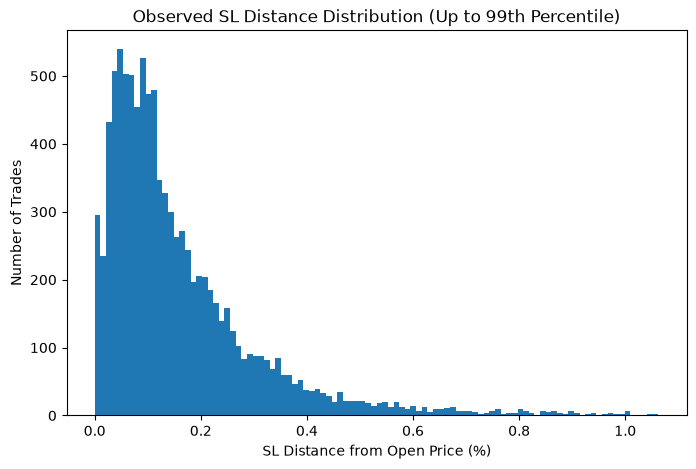

In [53]:
import matplotlib.pyplot as plt


sl_distances = (
    development_data["observed_sl_distance_pct"]
    .dropna()
    * 100
)

sl_p99 = sl_distances.quantile(0.99)

plt.figure(figsize=(8, 5))
plt.hist(
    sl_distances[sl_distances <= sl_p99],
    bins=100,
)

plt.xlabel("SL Distance from Open Price (%)")
plt.ylabel("Number of Trades")
plt.title("Observed SL Distance Distribution (Up to 99th Percentile)")
plt.show()

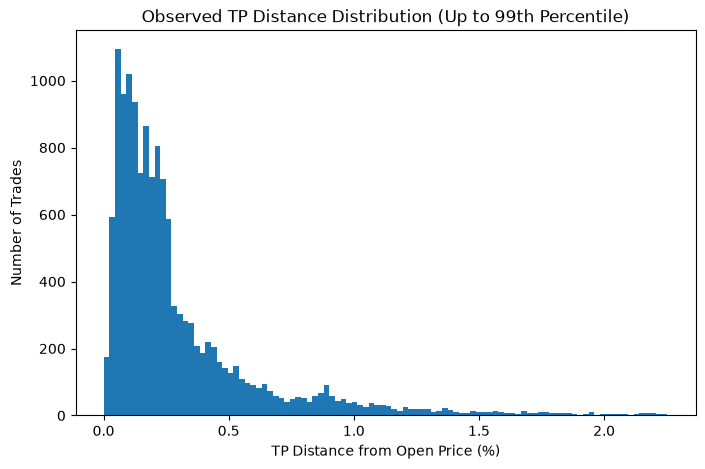

In [54]:
tp_distances = (
    development_data["observed_tp_distance_pct"]
    .dropna()
    * 100
)

tp_p99 = tp_distances.quantile(0.99)

plt.figure(figsize=(8, 5))
plt.hist(
    tp_distances[tp_distances <= tp_p99],
    bins=100,
)

plt.xlabel("TP Distance from Open Price (%)")
plt.ylabel("Number of Trades")
plt.title("Observed TP Distance Distribution (Up to 99th Percentile)")
plt.show()

### Upper-tail cutoff for clean regression target

In [55]:
sl_distance_upper_bound = (
    development_data["observed_sl_distance_pct"]
    .dropna()
    .quantile(0.99)
)

tp_distance_upper_bound = (
    development_data["observed_tp_distance_pct"]
    .dropna()
    .quantile(0.99)
)

print(
    f"SL upper bound: {sl_distance_upper_bound:.6f} "
    f"({sl_distance_upper_bound * 100:.3f}%)"
)

print(
    f"TP upper bound: {tp_distance_upper_bound:.6f} "
    f"({tp_distance_upper_bound * 100:.3f}%)"
)

SL upper bound: 0.010626 (1.063%)
TP upper bound: 0.022543 (2.254%)


In [56]:
trade_model_data["clean_sl_distance_pct"] = (
    trade_model_data["observed_sl_distance_pct"]
    .where(
        trade_model_data["observed_sl_distance_pct"]
        <= sl_distance_upper_bound
    )
)

trade_model_data["clean_tp_distance_pct"] = (
    trade_model_data["observed_tp_distance_pct"]
    .where(
        trade_model_data["observed_tp_distance_pct"]
        <= tp_distance_upper_bound
    )
)

In [57]:
sl_removed = (
    trade_model_data["observed_sl_distance_pct"].notna()
    & trade_model_data["clean_sl_distance_pct"].isna()
)

tp_removed = (
    trade_model_data["observed_tp_distance_pct"].notna()
    & trade_model_data["clean_tp_distance_pct"].isna()
)

print(
    f"SL distance observations excluded: "
    f"{sl_removed.sum():,} "
    f"({sl_removed.mean():.2%} of all trades)"
)

print(
    f"TP distance observations excluded: "
    f"{tp_removed.sum():,} "
    f"({tp_removed.mean():.2%} of all trades)"
)

SL distance observations excluded: 161 (0.35% of all trades)
TP distance observations excluded: 195 (0.42% of all trades)


### Rerun the walk-forward

In [58]:
development_data = trade_model_data.loc[
    trade_model_data["campaign_id"] <= 52
].copy()

In [59]:
sl_distance_predictions = {}

for model_name in [
    "linear_regression",
    "lightgbm",
    "xgboost",
    "catboost",
]:
    sl_distance_predictions[model_name] = (
        walk_forward_distance_model(
            data=development_data,
            feature_columns=sl_tp_distance_features,
            target_column="clean_sl_distance_pct",
            model_name=model_name,
            minimum_training_campaigns=10,
        )
    )

In [60]:
tp_distance_predictions = {}

for model_name in [
    "linear_regression",
    "lightgbm",
    "xgboost",
    "catboost",
]:
    tp_distance_predictions[model_name] = (
        walk_forward_distance_model(
            data=development_data,
            feature_columns=sl_tp_distance_features,
            target_column="clean_tp_distance_pct",
            model_name=model_name,
            minimum_training_campaigns=10,
        )
    )

In [61]:
comparison_records = []

for target_name, prediction_dict in [
    ("SL", sl_distance_predictions),
    ("TP", tp_distance_predictions),
]:
    for model_name, predictions in prediction_dict.items():
        metrics = evaluate_distance_predictions(
            predictions
        )

        comparison_records.append(
            {
                "target": target_name,
                "model": model_name,
                **metrics,
            }
        )

distance_model_comparison = pd.DataFrame(
    comparison_records
)

distance_model_comparison

,target,model,n_predictions,mae,median_absolute_error,r2
0,SL,linear_regression,5151,0.000921,0.000717,0.110047
1,SL,lightgbm,5151,0.000887,0.000624,0.115096
2,SL,xgboost,5151,0.000878,0.000630,0.129321
3,SL,catboost,5151,0.000865,0.000607,0.146239
4,TP,linear_regression,7134,0.001960,0.001525,0.139543
5,TP,lightgbm,7134,0.001700,0.000952,0.201379
6,TP,xgboost,7134,0.001731,0.000988,0.187113
7,TP,catboost,7134,0.001693,0.000971,0.215642


### Fit final SL/TP distance model

In [62]:
final_train_data = trade_model_data.loc[
    trade_model_data["campaign_id"] <= 52
].copy()

final_validation_data = trade_model_data.loc[
    trade_model_data["campaign_id"].between(53, 66)
].copy()

In [63]:
for dataset in [final_train_data, final_validation_data]:
    dataset["clean_sl_distance_pct"] = (
        dataset["observed_sl_distance_pct"]
        .where(
            dataset["observed_sl_distance_pct"]
            <= sl_distance_upper_bound
        )
    )

    dataset["clean_tp_distance_pct"] = (
        dataset["observed_tp_distance_pct"]
        .where(
            dataset["observed_tp_distance_pct"]
            <= tp_distance_upper_bound
        )
    )

In [64]:
sl_train = final_train_data.loc[
    final_train_data["clean_sl_distance_pct"].notna()
].copy()

final_sl_distance_model = build_distance_model(
    "catboost"
)

final_sl_distance_model.fit(
    sl_train[sl_tp_distance_features],
    sl_train["clean_sl_distance_pct"],
)

CatBoostRegressor(depth=6, iterations=200, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=False)

In [65]:
final_validation_data["predicted_sl_distance_pct"] = (
    final_sl_distance_model.predict(
        final_validation_data[sl_tp_distance_features]
    )
)

In [66]:
tp_train = final_train_data.loc[
    final_train_data["clean_tp_distance_pct"].notna()
].copy()

final_tp_distance_model = build_distance_model(
    "catboost"
)

final_tp_distance_model.fit(
    tp_train[sl_tp_distance_features],
    tp_train["clean_tp_distance_pct"],
)

CatBoostRegressor(depth=6, iterations=200, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=False)

In [67]:
final_validation_data["predicted_tp_distance_pct"] = (
    final_tp_distance_model.predict(
        final_validation_data[sl_tp_distance_features]
    )
)

In [68]:
sl_validation_mask = (
    final_validation_data["clean_sl_distance_pct"].notna()
)

sl_distance_validation_predictions = pd.DataFrame(
    {
        "observed_target": final_validation_data.loc[
            sl_validation_mask,
            "clean_sl_distance_pct",
        ],
        "predicted_distance": final_validation_data.loc[
            sl_validation_mask,
            "predicted_sl_distance_pct",
        ],
    }
)

sl_distance_validation_metrics = (
    evaluate_distance_predictions(
        sl_distance_validation_predictions
    )
)

In [69]:
tp_validation_mask = (
    final_validation_data["clean_tp_distance_pct"].notna()
)

tp_distance_validation_predictions = pd.DataFrame(
    {
        "observed_target": final_validation_data.loc[
            tp_validation_mask,
            "clean_tp_distance_pct",
        ],
        "predicted_distance": final_validation_data.loc[
            tp_validation_mask,
            "predicted_tp_distance_pct",
        ],
    }
)

tp_distance_validation_metrics = (
    evaluate_distance_predictions(
        tp_distance_validation_predictions
    )
)

In [70]:
print("SL distance validation")
for metric, value in sl_distance_validation_metrics.items():
    print(f"{metric}: {value:.6f}")

print("\nTP distance validation")
for metric, value in tp_distance_validation_metrics.items():
    print(f"{metric}: {value:.6f}")

SL distance validation
n_predictions: 8913.000000
mae: 0.000800
median_absolute_error: 0.000561
r2: 0.156692

TP distance validation
n_predictions: 11573.000000
mae: 0.001503
median_absolute_error: 0.000821
r2: 0.218229


# Add SL/TP features to master table

## Generate training OOF features

### Probability

In [71]:
sl_probability_oof = (
    sl_catboost_predictions[
        ["trade_row_id", "predicted_probability"]
    ]
    .rename(
        columns={
            "predicted_probability":
                "predicted_sl_probability"
        }
    )
)

tp_probability_oof = (
    tp_catboost_predictions[
        ["trade_row_id", "predicted_probability"]
    ]
    .rename(
        columns={
            "predicted_probability":
                "predicted_tp_probability"
        }
    )
)

### Distance

In [72]:
def walk_forward_distance_features(
    data,
    feature_columns,
    target_column,
    model_name,
    campaign_column="campaign_id",
    minimum_training_campaigns=10,
):
    """Generate out-of-fold distance predictions for all test trades.

    The model is trained only on historical rows with valid distance
    targets, while predictions are generated for every trade in the
    next campaign.

    Args:
        data: Trade-level DataFrame.
        feature_columns: Pre-trade predictor columns.
        target_column: Clean distance target.
        model_name: Regression model name.
        campaign_column: Campaign identifier column.
        minimum_training_campaigns: Minimum earlier campaigns required.

    Returns:
        DataFrame containing one predicted distance per eligible trade.
    """
    campaign_order = sorted(
        data[campaign_column].dropna().unique()
    )

    prediction_records = []

    for campaign_index, test_campaign in enumerate(campaign_order):
        training_campaigns = campaign_order[:campaign_index]

        if len(training_campaigns) < minimum_training_campaigns:
            continue

        train = data.loc[
            data[campaign_column].isin(training_campaigns)
            & data[target_column].notna()
        ].copy()

        test = data.loc[
            data[campaign_column] == test_campaign
        ].copy()

        if train.empty or test.empty:
            continue

        model = build_distance_model(model_name)

        model.fit(
            train[feature_columns],
            train[target_column],
        )

        predictions = test[
            ["trade_row_id"]
        ].copy()

        predictions["predicted_distance"] = (
            model.predict(
                test[feature_columns]
            )
        )

        prediction_records.append(predictions)

    return pd.concat(
        prediction_records,
        ignore_index=True,
    )

In [73]:
training_data = trade_model_data.loc[
    trade_model_data["campaign_id"] <= 52
].copy()

In [74]:
sl_distance_oof = walk_forward_distance_features(
    data=training_data,
    feature_columns=sl_tp_distance_features,
    target_column="clean_sl_distance_pct",
    model_name="catboost",
    minimum_training_campaigns=10,
)

sl_distance_oof = sl_distance_oof.rename(
    columns={
        "predicted_distance":
            "predicted_sl_distance_pct"
    }
)

In [75]:
tp_distance_oof = walk_forward_distance_features(
    data=training_data,
    feature_columns=sl_tp_distance_features,
    target_column="clean_tp_distance_pct",
    model_name="catboost",
    minimum_training_campaigns=10,
)

tp_distance_oof = tp_distance_oof.rename(
    columns={
        "predicted_distance":
            "predicted_tp_distance_pct"
    }
)

## Generate validation features

In [76]:
validation_features = trade_model_data.loc[
    trade_model_data["campaign_id"].between(53, 66)
].copy()

### Probability

In [77]:
final_sl_probability_model = build_probability_model(
    "catboost"
)

final_sl_probability_model.fit(
    training_data[sl_tp_probability_features],
    training_data["observed_has_sl"],
)

CatBoostClassifier(depth=6, iterations=200, learning_rate=0.05, random_seed=42, verbose=False)

In [78]:
final_tp_probability_model = build_probability_model(
    "catboost"
)

final_tp_probability_model.fit(
    training_data[sl_tp_probability_features],
    training_data["observed_has_tp"],
)

CatBoostClassifier(depth=6, iterations=200, learning_rate=0.05, random_seed=42, verbose=False)

In [79]:
validation_features["predicted_sl_probability"] = (
    final_sl_probability_model.predict_proba(
        validation_features[
            sl_tp_probability_features
        ]
    )[:, 1]
)

validation_features["predicted_tp_probability"] = (
    final_tp_probability_model.predict_proba(
        validation_features[
            sl_tp_probability_features
        ]
    )[:, 1]
)

### Distance

In [80]:
sl_distance_train = training_data.loc[
    training_data["clean_sl_distance_pct"].notna()
]

final_sl_distance_model = build_distance_model(
    "catboost"
)

final_sl_distance_model.fit(
    sl_distance_train[sl_tp_distance_features],
    sl_distance_train["clean_sl_distance_pct"],
)

CatBoostRegressor(depth=6, iterations=200, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=False)

In [81]:
tp_distance_train = training_data.loc[
    training_data["clean_tp_distance_pct"].notna()
]

final_tp_distance_model = build_distance_model(
    "catboost"
)

final_tp_distance_model.fit(
    tp_distance_train[sl_tp_distance_features],
    tp_distance_train["clean_tp_distance_pct"],
)

CatBoostRegressor(depth=6, iterations=200, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=False)

In [82]:
validation_features["predicted_sl_distance_pct"] = (
    final_sl_distance_model.predict(
        validation_features[
            sl_tp_distance_features
        ]
    )
)

validation_features["predicted_tp_distance_pct"] = (
    final_tp_distance_model.predict(
        validation_features[
            sl_tp_distance_features
        ]
    )
)

## Merge everything into trade_model_data

In [83]:
training_predicted_features = (
    sl_probability_oof
    .merge(
        tp_probability_oof,
        on="trade_row_id",
        validate="one_to_one",
    )
    .merge(
        sl_distance_oof,
        on="trade_row_id",
        validate="one_to_one",
    )
    .merge(
        tp_distance_oof,
        on="trade_row_id",
        validate="one_to_one",
    )
)

In [84]:
predicted_sl_tp_columns = [
    "predicted_sl_probability",
    "predicted_tp_probability",
    "predicted_sl_distance_pct",
    "predicted_tp_distance_pct",
]

validation_predicted_features = (
    validation_features[
        ["trade_row_id"] + predicted_sl_tp_columns
    ]
    .copy()
)

In [85]:
predicted_features = pd.concat(
    [
        training_predicted_features,
        validation_predicted_features,
    ],
    ignore_index=True,
)

In [86]:
trade_model_data = trade_model_data.merge(
    predicted_features,
    on="trade_row_id",
    how="left",
    validate="one_to_one",
)

# Create modelling table

In [250]:
predicted_sl_tp_columns = [
    "predicted_sl_probability",
    "predicted_tp_probability",
    "predicted_sl_distance_pct",
    "predicted_tp_distance_pct",
]

predicted_sl_tp_prob_columns = [
    "predicted_sl_probability",
    "predicted_tp_probability",
]

predicted_sl_tp_dist_columns = [
    "predicted_sl_distance_pct",
    "predicted_tp_distance_pct",
]

In [251]:
full_sl_tp_feature_columns = (
    available_feature_columns
    + predicted_sl_tp_columns
)

prob_only_feature_columns = (
    available_feature_columns
    + predicted_sl_tp_prob_columns
)

base_feature_columns = (
    available_feature_columns.copy()
)

full_sl_tp_feature_columns = list(
    dict.fromkeys(full_sl_tp_feature_columns)
)

prob_only_feature_columns = list(
    dict.fromkeys(prob_only_feature_columns)
)

base_feature_columns = list(
    dict.fromkeys(base_feature_columns)
)

In [252]:
identifier_columns = [
    "trade_row_id",
    "campaign_id",
    "account_id",
    "idea_id",
    "open_date_time",
    "close_date_time",
]

target_column = "reverse_profit_per_lot"

## Base features

In [253]:
base_model_columns = (
    identifier_columns
    + evaluation_columns
    + base_feature_columns
    + [target_column]
)

base_model_columns = list(
    dict.fromkeys(base_model_columns)
)

base_model_data = (
    trade_model_data[base_model_columns]
    .copy()
    .sort_values(
        [
            "campaign_id",
            "account_id",
            "open_date_time",
            "trade_row_id",
        ]
    )
    .reset_index(drop=True)
)

In [254]:
print(f"Modelling rows: {len(base_model_data):,}")
print(f"Predictor columns: {len(base_feature_columns)}")

Modelling rows: 46,520
Predictor columns: 40


## Base + full SL/TP features

In [255]:
full_sl_tp_model_columns = (
    identifier_columns
    + evaluation_columns
    + full_sl_tp_feature_columns
    + [target_column]
)

full_sl_tp_model_columns = list(
    dict.fromkeys(full_sl_tp_model_columns)
)

full_sl_tp_model_data = (
    trade_model_data[
        full_sl_tp_model_columns
    ]
    .copy()
    .sort_values(
        [
            "campaign_id",
            "account_id",
            "open_date_time",
            "trade_row_id",
        ]
    )
    .reset_index(drop=True)
)

In [257]:
print(f"Modelling rows: {len(full_sl_tp_model_data):,}")
print(f"Predictor columns: {len(full_sl_tp_feature_columns)}")

Modelling rows: 46,520
Predictor columns: 44


## Base + SL/TP probability features

In [258]:
prob_model_columns = (
    identifier_columns
    + evaluation_columns
    + prob_only_feature_columns
    + [target_column]
)

prob_model_columns = list(
    dict.fromkeys(prob_model_columns)
)

prob_model_data = (
    trade_model_data[
        prob_model_columns
    ]
    .copy()
    .sort_values(
        [
            "campaign_id",
            "account_id",
            "open_date_time",
            "trade_row_id",
        ]
    )
    .reset_index(drop=True)
)

In [259]:
print(f"Modelling rows: {len(prob_model_data):,}")
print(f"Predictor columns: {len(prob_only_feature_columns)}")

Modelling rows: 46,520
Predictor columns: 42


# Create train/validation split

## Train/validation split

In [260]:
base_train_data = (
    base_model_data.loc[
        base_model_data["campaign_id"] <= 52
    ]
    .copy()
    .reset_index(drop=True)
)

base_validation_data = (
    base_model_data.loc[
        base_model_data["campaign_id"].between(
            53,
            66,
        )
    ]
    .copy()
    .reset_index(drop=True)
)


full_sl_tp_train_data = (
    full_sl_tp_model_data.loc[
        full_sl_tp_model_data["campaign_id"] <= 52
    ]
    .copy()
    .reset_index(drop=True)
)

full_sl_tp_validation_data = (
    full_sl_tp_model_data.loc[
        full_sl_tp_model_data[
            "campaign_id"
        ].between(
            53,
            66,
        )
    ]
    .copy()
    .reset_index(drop=True)
)


prob_train_data = (
    prob_model_data.loc[
        prob_model_data["campaign_id"] <= 52
    ]
    .copy()
    .reset_index(drop=True)
)

prob_validation_data = (
    prob_model_data.loc[
        prob_model_data["campaign_id"].between(
            53,
            66,
        )
    ]
    .copy()
    .reset_index(drop=True)
)

In [261]:
base_train_data = (
    base_train_data
    .copy()
    .reset_index(drop=True)
)

In [262]:
full_sl_tp_train_data = (
    full_sl_tp_train_data.dropna(
        subset=predicted_sl_tp_columns
    )
    .reset_index(drop=True)
)

In [263]:
prob_train_data = (
    prob_train_data.dropna(
        subset=predicted_sl_tp_prob_columns
    )
    .reset_index(drop=True)
)

In [264]:
assert not full_sl_tp_validation_data[
    predicted_sl_tp_columns
].isna().any().any()

assert not prob_validation_data[
    predicted_sl_tp_prob_columns
].isna().any().any()

In [265]:
modelling_splits = {
    "base": (
        base_train_data,
        base_validation_data,
    ),
    "full_sl_tp": (
        full_sl_tp_train_data,
        full_sl_tp_validation_data,
    ),
    "prob_only": (
        prob_train_data,
        prob_validation_data,
    ),
}

for split_name, (
    train_split,
    validation_split,
) in modelling_splits.items():

    print(f"\n{split_name.upper()}")

    print(
        f"Training trades: "
        f"{len(train_split):,}"
    )

    print(
        f"Validation trades: "
        f"{len(validation_split):,}"
    )

    print(
        "Training campaigns:",
        sorted(
            train_split[
                "campaign_id"
            ].unique()
        ),
    )

    print(
        "Validation campaigns:",
        sorted(
            validation_split[
                "campaign_id"
            ].unique()
        ),
    )


BASE
Training trades: 25,165
Validation trades: 21,355
Training campaigns: [np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52)]
Validation campaigns: [np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66)]

FULL_SL_TP
Training trades: 12,771
Validation trades: 21,355
Training campaigns: [np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52)]
Validation campaigns: [np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(6

# Modelling framework

In [ ]:
from catboost import (
    CatBoostClassifier,
    CatBoostRegressor,
)
from lightgbm import (
    LGBMClassifier,
    LGBMRegressor,
)
from xgboost import (
    XGBClassifier,
    XGBRegressor,
)

from sklearn.ensemble import (
    ExtraTreesClassifier,
    ExtraTreesRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import (
    ElasticNet,
    HuberRegressor,
    LogisticRegression,
    Ridge,
)
from sklearn.neural_network import (
    MLPClassifier,
    MLPRegressor,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    RobustScaler,
    StandardScaler,
)
from sklearn.svm import (
    SVC,
    SVR,
)

## Classification models

In [96]:
def build_classifier(model_name):
    """Build a candidate classification model.

    Args:
        model_name: Name of the classifier.

    Returns:
        Configured classification model.
    """
    if model_name == "logistic_regression":
        return Pipeline(
            [
                (
                    "imputer",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    LogisticRegression(
                        max_iter=2000,
                        random_state=42,
                    ),
                ),
            ]
        )

    if model_name == "random_forest":
        return RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=20,
            random_state=42,
            n_jobs=-1,
        )

    if model_name == "extra_trees":
        return ExtraTreesClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=20,
            random_state=42,
            n_jobs=-1,
        )

    if model_name == "hist_gradient_boosting":
        return HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=200,
            max_leaf_nodes=15,
            l2_regularization=1.0,
            random_state=42,
        )

    if model_name == "lightgbm":
        return LGBMClassifier(
            n_estimators=200,
            learning_rate=0.05,
            num_leaves=15,
            random_state=42,
            verbosity=-1,
        )

    if model_name == "xgboost":
        return XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=42,
            n_jobs=-1,
            eval_metric="logloss",
        )

    if model_name == "catboost":
        return CatBoostClassifier(
            iterations=200,
            learning_rate=0.05,
            depth=6,
            random_seed=42,
            verbose=False,
        )

    if model_name == "svm":
        return Pipeline(
            [
                (
                    "imputer",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    SVC(
                        kernel="rbf",
                        C=1.0,
                        probability=True,
                        random_state=42,
                    ),
                ),
            ]
        )

    if model_name == "mlp":
        return Pipeline(
            [
                (
                    "imputer",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    MLPClassifier(
                        hidden_layer_sizes=(64, 32),
                        activation="relu",
                        alpha=0.001,
                        learning_rate_init=0.001,
                        early_stopping=True,
                        max_iter=300,
                        random_state=42,
                    ),
                ),
            ]
        )

    raise ValueError(
        f"Unknown classifier: {model_name}"
    )

## Regression models

In [97]:
def build_regressor(model_name):
    """Build a candidate regression model.

    Args:
        model_name: Name of the regressor.

    Returns:
        Configured regression model.
    """
    if model_name == "ridge":
        return Pipeline(
            [
                (
                    "imputer",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    Ridge(alpha=1.0),
                ),
            ]
        )

    if model_name == "elastic_net":
        return Pipeline(
            [
                (
                    "imputer",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    ElasticNet(
                        alpha=1.0,
                        l1_ratio=0.5,
                        max_iter=5000,
                        random_state=42,
                    ),
                ),
            ]
        )

    if model_name == "huber":
        return Pipeline(
            [
                (
                    "imputer",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "scaler",
                    RobustScaler(),
                ),
                (
                    "model",
                    HuberRegressor(
                        epsilon=1.35,
                        max_iter=1000,
                    ),
                ),
            ]
        )

    if model_name == "random_forest":
        return RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=20,
            random_state=42,
            n_jobs=-1,
        )

    if model_name == "extra_trees":
        return ExtraTreesRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=20,
            random_state=42,
            n_jobs=-1,
        )

    if model_name == "hist_gradient_boosting":
        return HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_iter=200,
            max_leaf_nodes=15,
            l2_regularization=1.0,
            random_state=42,
        )

    if model_name == "lightgbm":
        return LGBMRegressor(
            n_estimators=200,
            learning_rate=0.05,
            num_leaves=15,
            random_state=42,
            verbosity=-1,
        )

    if model_name == "xgboost":
        return XGBRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=42,
            n_jobs=-1,
        )

    if model_name == "catboost":
        return CatBoostRegressor(
            iterations=200,
            learning_rate=0.05,
            depth=6,
            random_seed=42,
            verbose=False,
        )

    if model_name == "svr":
        return Pipeline(
            [
                (
                    "imputer",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    SVR(
                        kernel="rbf",
                        C=1.0,
                        epsilon=0.1,
                    ),
                ),
            ]
        )

    if model_name == "mlp":
        return Pipeline(
            [
                (
                    "imputer",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    MLPRegressor(
                        hidden_layer_sizes=(64, 32),
                        activation="relu",
                        alpha=0.001,
                        learning_rate_init=0.001,
                        early_stopping=True,
                        max_iter=300,
                        random_state=42,
                    ),
                ),
            ]
        )

    raise ValueError(
        f"Unknown regressor: {model_name}"
    )

## Candidate model lists

In [98]:
classification_model_names = [
    "logistic_regression",
    "random_forest",
    "extra_trees",
    "hist_gradient_boosting",
    "lightgbm",
    "xgboost",
    "catboost",
    "svm",
    "mlp",
]

regression_model_names = [
    "ridge",
    "elastic_net",
    "huber",
    "random_forest",
    "extra_trees",
    "hist_gradient_boosting",
    "lightgbm",
    "xgboost",
    "catboost",
    "svr",
    "mlp",
]

## Walk-forward functions

In [99]:
def walk_forward_classifier(
    data,
    feature_columns,
    target_column,
    model_name,
    minimum_training_campaigns,
    campaign_column="campaign_id",
):
    """Generate walk-forward classification predictions.

    Args:
        data: Development modelling data.
        feature_columns: Predictor columns.
        target_column: Binary target column.
        model_name: Classification model name.
        minimum_training_campaigns: Minimum number of earlier
            campaigns required before evaluation.
        campaign_column: Campaign identifier column.

    Returns:
        DataFrame containing walk-forward probabilities and outcomes.
    """
    campaigns = sorted(
        data[campaign_column].unique()
    )

    predictions = []

    for test_index in range(
        minimum_training_campaigns,
        len(campaigns),
    ):
        test_campaign = campaigns[test_index]

        training_campaigns = campaigns[
            :test_index
        ]

        train = data.loc[
            data[campaign_column].isin(
                training_campaigns
            )
        ].copy()

        test = data.loc[
            data[campaign_column]
            == test_campaign
        ].copy()

        model = build_classifier(model_name)

        model.fit(
            train[feature_columns],
            train[target_column],
        )

        test_prediction = test[
            [
                "trade_row_id",
                "campaign_id",
                "account_id",
                "amount",
                "reverse_profit",
                "reverse_profit_per_lot",
                target_column,
            ]
        ].copy()

        test_prediction[
            "predicted_probability"
        ] = model.predict_proba(
            test[feature_columns]
        )[:, 1]

        test_prediction[
            "model_name"
        ] = model_name

        predictions.append(
            test_prediction
        )

    return pd.concat(
        predictions,
        ignore_index=True,
    )

In [100]:
def walk_forward_regressor(
    data,
    feature_columns,
    target_column,
    model_name,
    minimum_training_campaigns,
    campaign_column="campaign_id",
):
    """Generate walk-forward regression predictions.

    Args:
        data: Development modelling data.
        feature_columns: Predictor columns.
        target_column: Continuous regression target.
        model_name: Regression model name.
        minimum_training_campaigns: Minimum number of earlier
            campaigns required before evaluation.
        campaign_column: Campaign identifier column.

    Returns:
        DataFrame containing walk-forward predictions and outcomes.
    """
    campaigns = sorted(
        data[campaign_column].unique()
    )

    predictions = []

    for test_index in range(
        minimum_training_campaigns,
        len(campaigns),
    ):
        test_campaign = campaigns[test_index]

        training_campaigns = campaigns[
            :test_index
        ]

        train = data.loc[
            data[campaign_column].isin(
                training_campaigns
            )
        ].copy()

        test = data.loc[
            data[campaign_column]
            == test_campaign
        ].copy()

        model = build_regressor(model_name)

        model.fit(
            train[feature_columns],
            train[target_column],
        )

        test_prediction = test[
            [
                "trade_row_id",
                "campaign_id",
                "account_id",
                "amount",
                "reverse_profit",
                "reverse_profit_per_lot",
            ]
        ].copy()

        test_prediction[
            "predicted_reverse_profit_per_lot"
        ] = model.predict(
            test[feature_columns]
        )

        test_prediction[
            "model_name"
        ] = model_name

        predictions.append(
            test_prediction
        )

    return pd.concat(
        predictions,
        ignore_index=True,
    )

## Threshold / quantile evaluation functions

In [101]:
def evaluate_strategy(
    predictions,
    threshold,
    score_column,
):
    """Evaluate a fade strategy at a score threshold.

    Args:
        predictions: DataFrame containing model scores and realized outcomes.
        threshold: Minimum model score required to fade.
        score_column: Column containing the model score.

    Returns:
        Dictionary containing strategy performance metrics.
    """
    selected = predictions.loc[
        predictions[score_column] >= threshold
    ].copy()

    coverage = (
        len(selected) / len(predictions)
        if len(predictions) > 0
        else 0.0
    )

    if selected.empty:
        return {
            "n_faded": 0,
            "coverage": coverage,
            "mean_reverse_profit_per_lot": 0.0,
            "total_reverse_profit_per_total_lot": 0.0,
        }

    return {
        "n_faded": len(selected),
        "coverage": coverage,
        "mean_reverse_profit_per_lot": (
            selected[
                "reverse_profit_per_lot"
            ].mean()
        ),
        "total_reverse_profit_per_total_lot": (
            selected["reverse_profit"].sum()
            / selected["amount"].sum()
        ),
    }

In [ ]:
def evaluate_score_quantiles(
    predictions,
    score_column,
    
    ,
):
    """Evaluate strategy performance across score quantiles.

    Args:
        predictions: DataFrame containing model scores and outcomes.
        score_column: Column containing the model score.
        quantiles: Candidate quantiles used to define thresholds.

    Returns:
        DataFrame containing strategy performance by quantile.
    """
    results = []

    for quantile in quantiles:
        threshold = predictions[
            score_column
        ].quantile(quantile)

        metrics = evaluate_strategy(
            predictions=predictions,
            threshold=threshold,
            score_column=score_column,
        )

        results.append(
            {
                "quantile": quantile,
                "threshold": threshold,
                **metrics,
            }
        )

    return pd.DataFrame(results)

In [248]:
candidate_quantiles = [
    0.50,
    0.70,
    0.90,
]

## Campaign robustness functions

In [104]:
def evaluate_strategy_by_campaign(
    predictions,
    threshold,
    score_column,
    campaign_column="campaign_id",
):
    """Evaluate strategy performance separately by campaign.

    Args:
        predictions: DataFrame containing model scores and outcomes.
        threshold: Minimum model score required to fade.
        score_column: Column containing the model score.
        campaign_column: Campaign identifier column.

    Returns:
        DataFrame containing campaign-level strategy performance.
    """
    selected = predictions.loc[
        predictions[score_column] >= threshold
    ].copy()

    results = []

    for campaign_id, campaign_data in (
        predictions.groupby(campaign_column)
    ):
        campaign_selected = selected.loc[
            selected[campaign_column]
            == campaign_id
        ]

        n_trades = len(campaign_data)
        n_faded = len(campaign_selected)

        coverage = (
            n_faded / n_trades
            if n_trades > 0
            else 0.0
        )

        if n_faded == 0:
            mean_reverse_profit_per_lot = 0.0
            total_reverse_profit_per_total_lot = 0.0

        else:
            mean_reverse_profit_per_lot = (
                campaign_selected[
                    "reverse_profit_per_lot"
                ].mean()
            )

            total_reverse_profit_per_total_lot = (
                campaign_selected[
                    "reverse_profit"
                ].sum()
                / campaign_selected[
                    "amount"
                ].sum()
            )

        results.append(
            {
                "campaign_id": campaign_id,
                "n_trades": n_trades,
                "n_faded": n_faded,
                "coverage": coverage,
                "mean_reverse_profit_per_lot":
                    mean_reverse_profit_per_lot,
                "total_reverse_profit_per_total_lot":
                    total_reverse_profit_per_total_lot,
            }
        )

    return pd.DataFrame(results)

In [105]:
def summarize_campaign_robustness(
    campaign_results,
    metric_column=(
        "total_reverse_profit_per_total_lot"
    ),
):
    """Summarize strategy robustness across campaigns.

    Args:
        campaign_results: Campaign-level strategy results.
        metric_column: Metric used to define a positive campaign.

    Returns:
        Dictionary containing campaign robustness metrics.
    """
    metric = campaign_results[
        metric_column
    ]

    return {
        "n_campaigns": len(campaign_results),
        "positive_campaigns": (
            metric > 0
        ).sum(),
        "positive_campaign_share": (
            metric > 0
        ).mean(),
        "median_campaign_profit_per_lot":
            metric.median(),
    }

## Bootstrap functions

In [106]:
def account_cluster_bootstrap(
    predictions,
    threshold,
    score_column,
    n_bootstrap=2000,
    random_seed=RANDOM_SEED,
):
    """Bootstrap strategy performance by account.

    Args:
        predictions: Validation prediction DataFrame.
        threshold: Frozen strategy threshold.
        score_column: Column containing the model score.
        n_bootstrap: Number of bootstrap resamples.
        random_seed: Random seed for reproducibility.

    Returns:
        DataFrame containing bootstrap strategy metrics.
    """
    rng = np.random.default_rng(
        random_seed
    )

    accounts = predictions[
        "account_id"
    ].dropna().unique()

    bootstrap_results = []

    for bootstrap_id in range(
        n_bootstrap
    ):
        sampled_accounts = rng.choice(
            accounts,
            size=len(accounts),
            replace=True,
        )

        sampled_parts = []

        for sample_id, account_id in enumerate(
            sampled_accounts
        ):
            account_data = predictions.loc[
                predictions["account_id"]
                == account_id
            ].copy()

            account_data[
                "bootstrap_account_id"
            ] = sample_id

            sampled_parts.append(
                account_data
            )

        bootstrap_sample = pd.concat(
            sampled_parts,
            ignore_index=True,
        )

        metrics = evaluate_strategy(
            predictions=bootstrap_sample,
            threshold=threshold,
            score_column=score_column,
        )

        bootstrap_results.append(
            {
                "bootstrap_id":
                    bootstrap_id,
                **metrics,
            }
        )

    return pd.DataFrame(
        bootstrap_results
    )

In [137]:
def summarize_bootstrap(
    bootstrap_results,
    metric_column,
    confidence_level=0.95,
):
    """Summarize bootstrap uncertainty for one strategy metric.

    Args:
        bootstrap_results: DataFrame of bootstrap strategy results.
        metric_column: Metric column to summarize.
        confidence_level: Confidence interval level.

    Returns:
        Dictionary containing bootstrap summary statistics.
    """
    alpha = 1.0 - confidence_level

    values = bootstrap_results[
        metric_column
    ].dropna()

    return {
        "bootstrap_mean": values.mean(),
        "bootstrap_median": values.median(),
        "ci_lower": values.quantile(
            alpha / 2
        ),
        "ci_upper": values.quantile(
            1 - alpha / 2
        ),
        "positive_bootstrap_share": (
            values > 0
        ).mean(),
    }

# Modelling target

## Classification target

In [269]:
fade_target_column = "profitable_fade"

base_train_data[fade_target_column] = (
    base_train_data["reverse_profit_per_lot"] > 0
).astype(int)

base_validation_data[fade_target_column] = (
    base_validation_data["reverse_profit_per_lot"] > 0
).astype(int)

full_sl_tp_train_data[fade_target_column] = (
    full_sl_tp_train_data["reverse_profit_per_lot"] > 0
).astype(int)

full_sl_tp_validation_data[fade_target_column] = (
    full_sl_tp_validation_data["reverse_profit_per_lot"] > 0
).astype(int)

prob_train_data[fade_target_column] = (
    prob_train_data["reverse_profit_per_lot"] > 0
).astype(int)

prob_validation_data[fade_target_column] = (
    prob_validation_data["reverse_profit_per_lot"] > 0
).astype(int)

In [270]:
leaking_features = sorted(
    set(base_feature_columns)
    & set(banned_feature_columns)
)

assert not leaking_features, (
    "Leakage detected in final feature set: "
    + ", ".join(leaking_features)
)

assert target_column not in base_feature_columns

print("Final leakage check passed.")

Final leakage check passed.


# Baselines

## Do nothing

In [111]:
do_nothing_results = {
    "strategy": "Do Nothing",
    "n_trades": 0,
    "coverage": 0.0,
    "mean_reverse_profit_per_lot": 0.0,
    "total_reverse_profit_per_total_lot": 0.0,
}

## Fade everything

In [281]:
fade_everything_results = {
    "strategy": "Fade Everything",
    "n_trades": len(base_validation_data),
    "coverage": 1.0,
    "mean_reverse_profit_per_lot": (
        base_validation_data["reverse_profit_per_lot"].mean()
    ),
    "total_reverse_profit_per_total_lot": (
        base_validation_data["reverse_profit"].sum()
        / base_validation_data["amount"].sum()
    )
}

In [113]:
baseline_results = pd.DataFrame(
    [
        do_nothing_results,
        fade_everything_results,
    ]
)

baseline_results

,strategy,n_trades,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,Do Nothing,0,0.0,0.000000,0.000000
1,Fade Everything,21355,1.0,-3.904257,-3.586679


# Experiment 1: Classification with reconstructed SL/TP

## Experiment configuration

In [283]:
exp1_feature_columns = prob_only_feature_columns.copy()

exp1_train_data = prob_train_data.copy()

exp1_validation_data = prob_validation_data.copy()

exp1_score_column = "predicted_probability"

exp1_minimum_training_campaigns = 5

In [284]:
exp1_leaking_features = sorted(
    set(exp1_feature_columns)
    & set(banned_feature_columns)
)

assert not exp1_leaking_features, (
    "Leakage detected: "
    + ", ".join(exp1_leaking_features)
)

print(
    f"Number of features: "
    f"{len(exp1_feature_columns)}"
)

print(
    "Development campaigns:",
    sorted(
        exp1_train_data[
            "campaign_id"
        ].unique()
    ),
)

Number of features: 42
Development campaigns: [np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52)]


## Walk-forward model comparison

In [285]:
exp1_walk_forward_predictions = {}

for model_name in classification_model_names:
    exp1_walk_forward_predictions[
        model_name
    ] = walk_forward_classifier(
        data=exp1_train_data,
        feature_columns=exp1_feature_columns,
        target_column=fade_target_column,
        model_name=model_name,
        minimum_training_campaigns=(
            exp1_minimum_training_campaigns
        ),
    )

/Users/charltonsiaw/Desktop/C22-veNTUre/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/charltonsiaw/Desktop/C22-veNTUre/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/charltonsiaw/Desktop/C22-veNTUre/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/charltonsiaw/Desktop/C22-veNTUre/venv/lib/python3.13/site-packages/sklearn/

## Threshold selection

In [297]:
exp1_threshold_results = []

for model_name, predictions in (
    exp1_walk_forward_predictions.items()
):
    model_results = evaluate_score_quantiles(
        predictions=predictions,
        score_column=exp1_score_column,
        quantiles=candidate_quantiles,
    )

    model_results[
        "model_name"
    ] = model_name

    exp1_threshold_results.append(
        model_results
    )

exp1_threshold_results = (
    pd.concat(
        exp1_threshold_results,
        ignore_index=True,
    )
    .sort_values(
        "mean_reverse_profit_per_lot",
        ascending=False,
    )
    .reset_index(drop=True)
)

exp1_threshold_results

,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,model_name
0,0.7,0.516385,1848,0.300049,42.145016,10.747696,mlp
1,0.9,0.566189,616,0.100016,32.840569,-3.552976,extra_trees
2,0.7,0.494547,1848,0.300049,22.898777,9.590052,extra_trees
3,0.7,0.496146,1848,0.300049,20.611282,0.548159,logistic_regression
4,0.7,0.491681,1848,0.300049,19.785146,5.510280,random_forest
5,0.5,0.428753,3080,0.500081,18.115487,3.479036,svm
6,0.7,0.502091,1848,0.300049,17.219616,-1.769064,hist_gradient_boosting
7,0.7,0.492226,1848,0.300049,14.894935,-2.617937,svm
8,0.5,0.466299,3080,0.500081,12.457622,0.949654,random_forest
9,0.7,0.507706,1848,0.300049,12.199237,1.378194,lightgbm


In [298]:
exp1_best_results = (
    exp1_threshold_results
    .sort_values(
        "mean_reverse_profit_per_lot",
        ascending=False,
    )
    .groupby(
        "model_name",
        as_index=False,
    )
    .first()
    .sort_values(
        "mean_reverse_profit_per_lot",
        ascending=False,
    )
    .reset_index(drop=True)
)

exp1_best_results

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,mlp,0.7,0.516385,1848,0.300049,42.145016,10.747696
1,extra_trees,0.9,0.566189,616,0.100016,32.840569,-3.552976
2,logistic_regression,0.7,0.496146,1848,0.300049,20.611282,0.548159
3,random_forest,0.7,0.491681,1848,0.300049,19.785146,5.510280
4,svm,0.5,0.428753,3080,0.500081,18.115487,3.479036
5,hist_gradient_boosting,0.7,0.502091,1848,0.300049,17.219616,-1.769064
6,lightgbm,0.7,0.507706,1848,0.300049,12.199237,1.378194
7,catboost,0.5,0.466294,3080,0.500081,10.260389,-1.013455
8,xgboost,0.5,0.466676,3080,0.500081,-3.612316,-5.411843


## Development campaign robustness

In [299]:
exp1_robustness_results = []

for _, row in exp1_best_results.iterrows():
    model_name = row["model_name"]
    threshold = row["threshold"]

    campaign_results = (
        evaluate_strategy_by_campaign(
            predictions=(
                exp1_walk_forward_predictions[
                    model_name
                ]
            ),
            threshold=threshold,
            score_column=exp1_score_column,
        )
    )

    robustness = (
        summarize_campaign_robustness(
            campaign_results
        )
    )

    exp1_robustness_results.append(
        {
            "model_name": model_name,
            "quantile": row["quantile"],
            "threshold": threshold,
            "coverage": row["coverage"],
            "mean_reverse_profit_per_lot":
                row[
                    "mean_reverse_profit_per_lot"
                ],
            "total_reverse_profit_per_total_lot":
                row[
                    "total_reverse_profit_per_total_lot"
                ],
            **robustness,
        }
    )

exp1_robustness_results = (
    pd.DataFrame(
        exp1_robustness_results
    )
)

exp1_robustness_results

,model_name,quantile,threshold,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,mlp,0.7,0.516385,0.300049,42.145016,10.747696,5,3,0.6,20.864123
1,extra_trees,0.9,0.566189,0.100016,32.840569,-3.552976,5,3,0.6,7.811772
2,logistic_regression,0.7,0.496146,0.300049,20.611282,0.548159,5,1,0.2,-7.696178
3,random_forest,0.7,0.491681,0.300049,19.785146,5.510280,5,4,0.8,2.070738
4,svm,0.5,0.428753,0.500081,18.115487,3.479036,5,2,0.4,-7.486508
5,hist_gradient_boosting,0.7,0.502091,0.300049,17.219616,-1.769064,5,2,0.4,-7.042829
6,lightgbm,0.7,0.507706,0.300049,12.199237,1.378194,5,1,0.2,-7.567644
7,catboost,0.5,0.466294,0.500081,10.260389,-1.013455,5,3,0.6,1.198915
8,xgboost,0.5,0.466676,0.500081,-3.612316,-5.411843,5,2,0.4,-11.138156


## Candidate selection

In [300]:
exp1_selected_model_name = "mlp"
exp1_selected_quantile = 0.70

exp1_selected_result = (
    exp1_threshold_results.loc[
        (
            exp1_threshold_results[
                "model_name"
            ]
            == exp1_selected_model_name
        )
        & (
            exp1_threshold_results[
                "quantile"
            ]
            == exp1_selected_quantile
        )
    ]
    .iloc[0]
)

exp1_selected_threshold = (
    exp1_selected_result["threshold"]
)

print(
    f"Selected model: "
    f"{exp1_selected_model_name}"
)

print(
    f"Selected quantile: "
    f"{exp1_selected_quantile:.2f}"
)

print(
    f"Frozen threshold: "
    f"{exp1_selected_threshold:.6f}"
)

Selected model: mlp
Selected quantile: 0.70
Frozen threshold: 0.516385


## Fit selected model on all development campaigns

In [301]:
exp1_X_train = (
    exp1_train_data[
        exp1_feature_columns
    ].copy()
)

exp1_y_train = (
    exp1_train_data[
        fade_target_column
    ].copy()
)

exp1_X_validation = (
    exp1_validation_data[
        exp1_feature_columns
    ].copy()
)

In [302]:
exp1_final_model = build_classifier(
    exp1_selected_model_name
)

exp1_final_model.fit(
    exp1_X_train,
    exp1_y_train,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](42,)","['post_loss_entry','post_loss_reentry_gap_minutes', 'post_loss_amount_ratio',...,'past_payoff_ratio', 'predicted_sl_probability','predicted_tp_probability']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,42
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", 

## Validation on campaigns 53-66

In [303]:
exp1_validation_predictions = (
    exp1_validation_data[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "amount",
            "reverse_profit",
            "reverse_profit_per_lot",
            fade_target_column,
        ]
    ]
    .copy()
)

exp1_validation_predictions[
    exp1_score_column
] = exp1_final_model.predict_proba(
    exp1_X_validation
)[:, 1]

In [304]:
exp1_validation_result = (
    evaluate_strategy(
        predictions=(
            exp1_validation_predictions
        ),
        threshold=(
            exp1_selected_threshold
        ),
        score_column=exp1_score_column,
    )
)

exp1_validation_result

{'n_faded': 7282,
 'coverage': 0.3409974244907516,
 'mean_reverse_profit_per_lot': np.float64(0.6090454910694778),
 'total_reverse_profit_per_total_lot': np.float64(0.5206414438233722)}

## Validation campaign robustness

In [305]:
exp1_validation_by_campaign = (
    evaluate_strategy_by_campaign(
        predictions=(
            exp1_validation_predictions
        ),
        threshold=(
            exp1_selected_threshold
        ),
        score_column=exp1_score_column,
    )
)

exp1_validation_by_campaign

,campaign_id,n_trades,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,53,1063,373,0.350894,78.428418,21.687854
1,54,1511,498,0.329583,-9.162701,12.278054
2,55,1222,380,0.310966,-36.195605,-13.751280
3,56,1732,527,0.304273,-84.868989,-39.059777
4,57,1256,432,0.343949,50.840278,42.632714
5,58,1263,362,0.286619,15.153315,14.319108
6,59,1490,482,0.323490,25.121055,11.979700
7,60,1575,520,0.330159,48.525481,26.078061
8,61,1573,620,0.394151,21.174839,17.880374
9,62,1602,551,0.343945,-4.508671,-24.665912


In [306]:
exp1_validation_robustness = (
    summarize_campaign_robustness(
        exp1_validation_by_campaign
    )
)

exp1_validation_robustness

{'n_campaigns': 14,
 'positive_campaigns': np.int64(9),
 'positive_campaign_share': np.float64(0.6428571428571429),
 'median_campaign_profit_per_lot': np.float64(9.496616862063975)}

## Account-cluster bootstrap

In [307]:
exp1_bootstrap_results = (
    account_cluster_bootstrap(
        predictions=(
            exp1_validation_predictions
        ),
        threshold=(
            exp1_selected_threshold
        ),
        score_column=exp1_score_column,
        n_bootstrap=N_BOOTSTRAP,
        random_seed=RANDOM_SEED,
    )
)

In [308]:
exp1_bootstrap_summary = pd.DataFrame(
    [
        {
            "metric":
                "mean_reverse_profit_per_lot",
            **summarize_bootstrap(
                bootstrap_results=(
                    exp1_bootstrap_results
                ),
                metric_column=(
                    "mean_reverse_profit_per_lot"
                ),
            ),
        },
        {
            "metric":
                "total_reverse_profit_per_total_lot",
            **summarize_bootstrap(
                bootstrap_results=(
                    exp1_bootstrap_results
                ),
                metric_column=(
                    "total_reverse_profit_per_total_lot"
                ),
            ),
        },
    ]
)

exp1_bootstrap_summary

,metric,bootstrap_mean,bootstrap_median,ci_lower,ci_upper,positive_bootstrap_share
0,mean_reverse_profit_per_lot,0.945861,1.005602,-15.267948,17.320723,0.547
1,total_reverse_profit_per_total_lot,0.551585,0.389044,-10.576945,11.440725,0.533


# Experiment 2: Stage-2-screened features

## Experiment configuration

In [ ]:
exp2_base_feature_columns = [
    "realized_distance_to_drawdown_limit",
    "past_amount_cv",
]

exp2_feature_columns = (
    exp2_base_feature_columns
    + predicted_sl_tp_prob_columns
)

exp2_feature_columns = list(
    dict.fromkeys(exp2_feature_columns)
)

exp2_train_data = (
    prob_train_data.copy()
)

exp2_validation_data = (
    prob_validation_data.copy()
)

exp2_score_column = (
    "predicted_probability"
)

exp2_minimum_training_campaigns = 5

In [188]:
exp2_leaking_features = sorted(
    set(exp2_feature_columns)
    & set(banned_feature_columns)
)

assert not exp2_leaking_features, (
    "Leakage detected: "
    + ", ".join(exp2_leaking_features)
)

print(
    f"Number of features: "
    f"{len(exp2_feature_columns)}"
)

print(
    "Development campaigns:",
    sorted(
        exp2_train_data[
            "campaign_id"
        ].unique()
    ),
)

print(
    "Features:",
    exp2_feature_columns,
)

Number of features: 6
Development campaigns: [np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52)]
Features: ['realized_distance_to_drawdown_limit', 'past_amount_cv', 'predicted_sl_probability', 'predicted_tp_probability', 'predicted_sl_distance_pct', 'predicted_tp_distance_pct']


## Walk-forward model comparison

In [189]:
exp2_walk_forward_predictions = {}

for model_name in classification_model_names:
    exp2_walk_forward_predictions[
        model_name
    ] = walk_forward_classifier(
        data=exp2_train_data,
        feature_columns=exp2_feature_columns,
        target_column=fade_target_column,
        model_name=model_name,
        minimum_training_campaigns=(
            exp2_minimum_training_campaigns
        ),
    )

/Users/charltonsiaw/Desktop/C22-veNTUre/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/charltonsiaw/Desktop/C22-veNTUre/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/charltonsiaw/Desktop/C22-veNTUre/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/charltonsiaw/Desktop/C22-veNTUre/venv/lib/python3.13/site-packages/sklearn/

## Threshold selection

In [190]:
exp2_threshold_results = []

for model_name, predictions in (
    exp2_walk_forward_predictions.items()
):
    model_results = evaluate_score_quantiles(
        predictions=predictions,
        score_column=exp2_score_column,
        quantiles=candidate_quantiles,
    )

    model_results["model_name"] = (
        model_name
    )

    exp2_threshold_results.append(
        model_results
    )

exp2_threshold_results = (
    pd.concat(
        exp2_threshold_results,
        ignore_index=True,
    )
    .sort_values(
        "mean_reverse_profit_per_lot",
        ascending=False,
    )
    .reset_index(drop=True)
)

exp2_threshold_results

,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,model_name
0,0.9,0.582840,616,0.100016,69.334400,32.443751,hist_gradient_boosting
1,0.9,0.598693,616,0.100016,63.684957,12.698432,lightgbm
2,0.9,0.593952,616,0.100016,46.732127,9.507448,xgboost
3,0.8,0.537255,1232,0.200032,39.482135,7.679001,hist_gradient_boosting
4,0.8,0.502834,1232,0.200032,36.883515,10.306115,extra_trees
5,0.7,0.478310,1848,0.300049,35.920558,12.253551,svm
6,0.8,0.540778,1232,0.200032,35.254457,-0.156460,xgboost
7,0.9,0.575609,616,0.100016,32.634416,10.446818,logistic_regression
8,0.8,0.528699,1232,0.200032,30.274668,13.681520,svm
9,0.8,0.527912,1232,0.200032,29.899099,2.888413,random_forest


In [191]:
exp2_best_results = (
    exp2_threshold_results
    .sort_values(
        "mean_reverse_profit_per_lot",
        ascending=False,
    )
    .groupby(
        "model_name",
        as_index=False,
    )
    .first()
    .sort_values(
        "mean_reverse_profit_per_lot",
        ascending=False,
    )
    .reset_index(drop=True)
)

exp2_best_results

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,hist_gradient_boosting,0.9,0.582840,616,0.100016,69.334400,32.443751
1,lightgbm,0.9,0.598693,616,0.100016,63.684957,12.698432
2,xgboost,0.9,0.593952,616,0.100016,46.732127,9.507448
3,extra_trees,0.8,0.502834,1232,0.200032,36.883515,10.306115
4,svm,0.7,0.478310,1848,0.300049,35.920558,12.253551
5,logistic_regression,0.9,0.575609,616,0.100016,32.634416,10.446818
6,random_forest,0.8,0.527912,1232,0.200032,29.899099,2.888413
7,catboost,0.7,0.497250,1848,0.300049,21.446018,3.365958
8,mlp,0.8,0.544321,1232,0.200032,8.127016,-4.687527


## Development campaign robustness

In [192]:
exp2_robustness_results = []

for _, row in exp2_best_results.iterrows():
    model_name = row["model_name"]
    threshold = row["threshold"]

    campaign_results = (
        evaluate_strategy_by_campaign(
            predictions=(
                exp2_walk_forward_predictions[
                    model_name
                ]
            ),
            threshold=threshold,
            score_column=exp2_score_column,
        )
    )

    robustness = (
        summarize_campaign_robustness(
            campaign_results
        )
    )

    exp2_robustness_results.append(
        {
            "model_name": model_name,
            "quantile": row["quantile"],
            "threshold": threshold,
            "coverage": row["coverage"],
            "mean_reverse_profit_per_lot":
                row[
                    "mean_reverse_profit_per_lot"
                ],
            "total_reverse_profit_per_total_lot":
                row[
                    "total_reverse_profit_per_total_lot"
                ],
            **robustness,
        }
    )

exp2_robustness_results = pd.DataFrame(
    exp2_robustness_results
)

exp2_robustness_results

,model_name,quantile,threshold,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,hist_gradient_boosting,0.9,0.582840,0.100016,69.334400,32.443751,5,4,0.8,25.273909
1,lightgbm,0.9,0.598693,0.100016,63.684957,12.698432,5,4,0.8,3.508399
2,xgboost,0.9,0.593952,0.100016,46.732127,9.507448,5,3,0.6,25.311072
3,extra_trees,0.8,0.502834,0.200032,36.883515,10.306115,5,3,0.6,2.404162
4,svm,0.7,0.478310,0.300049,35.920558,12.253551,5,3,0.6,5.785157
5,logistic_regression,0.9,0.575609,0.100016,32.634416,10.446818,5,4,0.8,44.253459
6,random_forest,0.8,0.527912,0.200032,29.899099,2.888413,5,2,0.4,-15.254405
7,catboost,0.7,0.497250,0.300049,21.446018,3.365958,5,2,0.4,-12.384284
8,mlp,0.8,0.544321,0.200032,8.127016,-4.687527,5,1,0.2,-9.027463


## Candidate selection

In [193]:
exp2_selected_model_name = "hist_gradient_boosting"
exp2_selected_quantile = 0.90

In [194]:
exp2_selected_result = (
    exp2_threshold_results.loc[
        (
            exp2_threshold_results[
                "model_name"
            ]
            == exp2_selected_model_name
        )
        & (
            exp2_threshold_results[
                "quantile"
            ]
            == exp2_selected_quantile
        )
    ]
    .iloc[0]
)

exp2_selected_threshold = (
    exp2_selected_result["threshold"]
)

print(
    f"Selected model: "
    f"{exp2_selected_model_name}"
)

print(
    f"Selected quantile: "
    f"{exp2_selected_quantile:.2f}"
)

print(
    f"Frozen threshold: "
    f"{exp2_selected_threshold:.6f}"
)

Selected model: hist_gradient_boosting
Selected quantile: 0.90
Frozen threshold: 0.582840


## Fit selected model on all development campaigns

In [195]:
exp2_X_train = (
    exp2_train_data[
        exp2_feature_columns
    ].copy()
)

exp2_y_train = (
    exp2_train_data[
        fade_target_column
    ].copy()
)

exp2_X_validation = (
    exp2_validation_data[
        exp2_feature_columns
    ].copy()
)

In [196]:
exp2_final_model = build_classifier(
    exp2_selected_model_name
)

exp2_final_model.fit(
    exp2_X_train,
    exp2_y_train,
)

,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",200
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",15
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",1.0
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing va

## Validation on campaigns 53-66

In [197]:
exp2_validation_predictions = (
    exp2_validation_data[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "amount",
            "reverse_profit",
            "reverse_profit_per_lot",
            fade_target_column,
        ]
    ]
    .copy()
)

exp2_validation_predictions[
    exp2_score_column
] = exp2_final_model.predict_proba(
    exp2_X_validation
)[:, 1]

In [198]:
exp2_validation_result = (
    evaluate_strategy(
        predictions=(
            exp2_validation_predictions
        ),
        threshold=(
            exp2_selected_threshold
        ),
        score_column=exp2_score_column,
    )
)

exp2_validation_result

{'n_faded': 2683,
 'coverage': 0.12563802388199485,
 'mean_reverse_profit_per_lot': np.float64(-13.137681793002821),
 'total_reverse_profit_per_total_lot': np.float64(-15.115637923112272)}

## Validation campaign robustness

In [199]:
exp2_validation_by_campaign = (
    evaluate_strategy_by_campaign(
        predictions=(
            exp2_validation_predictions
        ),
        threshold=(
            exp2_selected_threshold
        ),
        score_column=exp2_score_column,
    )
)

exp2_validation_by_campaign

,campaign_id,n_trades,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,53,1063,154,0.144873,-37.596104,-18.762571
1,54,1511,228,0.150893,32.289364,23.628653
2,55,1222,169,0.138298,-30.603550,-35.268506
3,56,1732,222,0.128176,-168.559524,-83.819019
4,57,1256,202,0.160828,-16.326733,3.594529
5,58,1263,154,0.121932,75.084416,22.967535
6,59,1490,167,0.112081,-4.862275,-15.187320
7,60,1575,211,0.133968,44.236730,5.638792
8,61,1573,195,0.123967,-15.394872,-6.190971
9,62,1602,175,0.109238,-20.017143,-22.383980


In [200]:
exp2_validation_robustness = (
    summarize_campaign_robustness(
        exp2_validation_by_campaign
    )
)

exp2_validation_robustness

{'n_campaigns': 14,
 'positive_campaigns': np.int64(5),
 'positive_campaign_share': np.float64(0.35714285714285715),
 'median_campaign_profit_per_lot': np.float64(-10.689145669293849)}

## Account-cluster bootstrap

In [201]:
exp2_bootstrap_results = (
    account_cluster_bootstrap(
        predictions=(
            exp2_validation_predictions
        ),
        threshold=(
            exp2_selected_threshold
        ),
        score_column=exp2_score_column,
        n_bootstrap=1000,
        random_seed=RANDOM_SEED,
    )
)

In [186]:
exp2_bootstrap_summary = pd.DataFrame(
    [
        {
            "metric":
                "mean_reverse_profit_per_lot",
            **summarize_bootstrap(
                bootstrap_results=(
                    exp2_bootstrap_results
                ),
                metric_column=(
                    "mean_reverse_profit_per_lot"
                ),
            ),
        },
        {
            "metric":
                "total_reverse_profit_per_total_lot",
            **summarize_bootstrap(
                bootstrap_results=(
                    exp2_bootstrap_results
                ),
                metric_column=(
                    "total_reverse_profit_per_total_lot"
                ),
            ),
        },
    ]
)

exp2_bootstrap_summary

,metric,bootstrap_mean,bootstrap_median,ci_lower,ci_upper,positive_bootstrap_share
0,mean_reverse_profit_per_lot,-12.514972,-12.661323,-36.601104,12.996664,0.172
1,total_reverse_profit_per_total_lot,-12.906053,-13.050900,-28.016841,2.995658,0.055


# Experiment 3: Classification without SL/TP

## Experiment configuration

In [229]:
exp3_feature_columns = (
    available_feature_columns.copy()
)

exp3_score_column = (
    "predicted_probability"
)

exp3_minimum_training_campaigns = 10

## Build expanded modelling sample

In [230]:
exp3_model_columns = (
    identifier_columns
    + evaluation_columns
    + exp3_feature_columns
    + [target_column]
)

exp3_model_columns = list(
    dict.fromkeys(exp3_model_columns)
)

exp3_data = (
    trade_model_data[
        exp3_model_columns
    ]
    .copy()
    .sort_values(
        [
            "campaign_id",
            "account_id",
            "open_date_time",
            "trade_row_id",
        ]
    )
    .reset_index(drop=True)
)

## Train/validation split

In [231]:
exp3_train_data = (
    exp3_data.loc[
        exp3_data["campaign_id"] <= 52
    ]
    .copy()
    .reset_index(drop=True)
)

exp3_validation_data = (
    exp3_data.loc[
        exp3_data["campaign_id"].between(
            53,
            66,
        )
    ]
    .copy()
    .reset_index(drop=True)
)

## Create classification target

In [232]:
exp3_train_data[
    fade_target_column
] = (
    exp3_train_data[
        "reverse_profit_per_lot"
    ] > 0
).astype(int)

exp3_validation_data[
    fade_target_column
] = (
    exp3_validation_data[
        "reverse_profit_per_lot"
    ] > 0
).astype(int)

In [233]:
print(
    "Development campaigns:",
    sorted(
        exp3_train_data[
            "campaign_id"
        ].unique()
    ),
)

print(
    "Number of development campaigns:",
    exp3_train_data[
        "campaign_id"
    ].nunique(),
)

print(
    "Development trades:",
    len(exp3_train_data),
)

print(
    "Validation campaigns:",
    sorted(
        exp3_validation_data[
            "campaign_id"
        ].unique()
    ),
)

print(
    "Validation trades:",
    len(exp3_validation_data),
)

print(
    "Number of features:",
    len(exp3_feature_columns),
)

Development campaigns: [np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52)]
Number of development campaigns: 20
Development trades: 25165
Validation campaigns: [np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66)]
Validation trades: 21355
Number of features: 40


In [234]:
exp3_leaking_features = sorted(
    set(exp3_feature_columns)
    & set(banned_feature_columns)
)

assert not exp3_leaking_features, (
    "Leakage detected: "
    + ", ".join(exp3_leaking_features)
)

assert (
    target_column
    not in exp3_feature_columns
)

print("Experiment 3 leakage check passed.")

Experiment 3 leakage check passed.


## Walk-forward model comparison

In [235]:
exp3_walk_forward_predictions = {}

for model_name in classification_model_names:
    exp3_walk_forward_predictions[
        model_name
    ] = walk_forward_classifier(
        data=exp3_train_data,
        feature_columns=exp3_feature_columns,
        target_column=fade_target_column,
        model_name=model_name,
        minimum_training_campaigns=(
            exp3_minimum_training_campaigns
        ),
    )

/Users/charltonsiaw/Desktop/C22-veNTUre/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/charltonsiaw/Desktop/C22-veNTUre/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/charltonsiaw/Desktop/C22-veNTUre/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/charltonsiaw/Desktop/C22-veNTUre/venv/lib/python3.13/site-packages/sklearn/

## Threshold selection

In [236]:
exp3_threshold_results = []

for model_name, predictions in (
    exp3_walk_forward_predictions.items()
):
    model_results = (
        evaluate_score_quantiles(
            predictions=predictions,
            score_column=exp3_score_column,
            quantiles=candidate_quantiles,
        )
    )

    model_results[
        "model_name"
    ] = model_name

    exp3_threshold_results.append(
        model_results
    )

exp3_threshold_results = (
    pd.concat(
        exp3_threshold_results,
        ignore_index=True,
    )
    .sort_values(
        "mean_reverse_profit_per_lot",
        ascending=False,
    )
    .reset_index(drop=True)
)

exp3_threshold_results

,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,model_name
0,0.9,0.563105,1278,0.100070,24.239593,16.354240,hist_gradient_boosting
1,0.9,0.576245,1278,0.100070,23.840344,16.182557,svm
2,0.8,0.540342,2555,0.200063,18.182058,10.166377,svm
3,0.9,0.580733,1278,0.100070,14.919920,8.031594,lightgbm
4,0.9,0.560714,1278,0.100070,14.591862,6.472176,extra_trees
5,0.9,0.580465,1278,0.100070,13.713928,2.317998,catboost
6,0.8,0.526161,2555,0.200063,12.475499,9.611049,hist_gradient_boosting
7,0.8,0.530378,2555,0.200063,10.364383,4.148816,random_forest
8,0.7,0.493986,3832,0.300055,9.730076,9.904821,catboost
9,0.6,0.473669,5112,0.400282,8.335918,6.635199,xgboost


## Candidate evaluation and campaign robustness

In [237]:
exp3_candidate_results = []

for model_name, predictions in (
    exp3_walk_forward_predictions.items()
):
    for quantile in candidate_quantiles:
        threshold = predictions[
            exp3_score_column
        ].quantile(quantile)

        strategy_result = (
            evaluate_strategy(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp3_score_column
                ),
            )
        )

        campaign_results = (
            evaluate_strategy_by_campaign(
                predictions=predictions,
                threshold=threshold,
                score_column=(
                    exp3_score_column
                ),
            )
        )

        robustness = (
            summarize_campaign_robustness(
                campaign_results
            )
        )

        exp3_candidate_results.append(
            {
                "model_name": model_name,
                "quantile": quantile,
                "threshold": threshold,
                **strategy_result,
                **robustness,
            }
        )

exp3_candidate_results = pd.DataFrame(
    exp3_candidate_results
)

exp3_candidate_results

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,logistic_regression,0.5,0.446536,6386,0.500039,0.200713,3.360152,10,4,0.4,-2.910879
1,logistic_regression,0.6,0.464831,5109,0.400047,-2.382123,-1.421346,10,4,0.4,-6.265959
2,logistic_regression,0.7,0.503660,3832,0.300055,6.915017,6.404500,10,3,0.3,-2.721616
3,logistic_regression,0.8,0.544070,2555,0.200063,5.981912,0.944165,10,4,0.4,-4.911219
4,logistic_regression,0.9,0.580400,1278,0.100070,-11.229785,1.991870,10,4,0.4,-3.109229
5,random_forest,0.5,0.456253,6386,0.500039,6.433811,5.839548,10,5,0.5,1.687471
6,random_forest,0.6,0.468506,5109,0.400047,2.636206,9.236576,10,5,0.5,-1.443760
7,random_forest,0.7,0.494574,3832,0.300055,6.881319,8.524136,10,4,0.4,-4.468173
8,random_forest,0.8,0.530378,2555,0.200063,10.364383,4.148816,10,3,0.3,-6.010030
9,random_forest,0.9,0.574084,1278,0.100070,-2.847425,-2.843369,10,5,0.5,-8.683120


In [238]:
exp3_promising_candidates = (
    exp3_candidate_results.loc[
        (
            exp3_candidate_results[
                "mean_reverse_profit_per_lot"
            ] > 0
        )
        & (
            exp3_candidate_results[
                "total_reverse_profit_per_total_lot"
            ] > 0
        )
        & (
            exp3_candidate_results[
                "positive_campaign_share"
            ] >= 0.50
        )
        & (
            exp3_candidate_results[
                "median_campaign_profit_per_lot"
            ] > 0
        )
    ]
    .copy()
)

exp3_promising_candidates = (
    exp3_promising_candidates
    .sort_values(
        [
            "positive_campaign_share",
            "median_campaign_profit_per_lot",
            "total_reverse_profit_per_total_lot",
            "mean_reverse_profit_per_lot",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

exp3_promising_candidates

,model_name,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,n_campaigns,positive_campaigns,positive_campaign_share,median_campaign_profit_per_lot
0,mlp,0.5,0.459040,6386,0.500039,4.386956,2.681711,10,7,0.7,7.881143
1,svm,0.9,0.576245,1278,0.100070,23.840344,16.182557,10,6,0.6,8.278435
2,lightgbm,0.9,0.580733,1278,0.100070,14.919920,8.031594,10,6,0.6,7.469890
3,mlp,0.7,0.513822,3832,0.300055,4.028241,0.372946,10,6,0.6,7.218861
4,extra_trees,0.9,0.560714,1278,0.100070,14.591862,6.472176,10,6,0.6,6.825987
5,xgboost,0.6,0.473669,5112,0.400282,8.335918,6.635199,10,6,0.6,1.847661
6,hist_gradient_boosting,0.9,0.563105,1278,0.100070,24.239593,16.354240,10,5,0.5,9.105646
7,lightgbm,0.8,0.532940,2555,0.200063,7.724013,9.902304,10,5,0.5,6.077486
8,random_forest,0.5,0.456253,6386,0.500039,6.433811,5.839548,10,5,0.5,1.687471
9,hist_gradient_boosting,0.5,0.457989,6387,0.500117,0.838795,3.661141,10,5,0.5,1.604655


## Candidate selection

In [239]:
if exp3_promising_candidates.empty:
    print(
        "No Experiment 3 candidate "
        "passed the robustness criteria."
    )
else:
    exp3_selected_result = (
        exp3_promising_candidates.iloc[0]
    )

    exp3_selected_model_name = (
        exp3_selected_result[
            "model_name"
        ]
    )

    exp3_selected_quantile = (
        exp3_selected_result[
            "quantile"
        ]
    )

    exp3_selected_threshold = (
        exp3_selected_result[
            "threshold"
        ]
    )

    print(
        f"Selected model: "
        f"{exp3_selected_model_name}"
    )

    print(
        f"Selected quantile: "
        f"{exp3_selected_quantile:.2f}"
    )

    print(
        f"Frozen threshold: "
        f"{exp3_selected_threshold:.6f}"
    )

Selected model: mlp
Selected quantile: 0.50
Frozen threshold: 0.459040


## Fit selected model on all development campaigns

In [240]:
exp3_X_train = (
    exp3_train_data[
        exp3_feature_columns
    ].copy()
)

exp3_y_train = (
    exp3_train_data[
        fade_target_column
    ].copy()
)

exp3_X_validation = (
    exp3_validation_data[
        exp3_feature_columns
    ].copy()
)

In [241]:
exp3_final_model = build_classifier(
    exp3_selected_model_name
)

exp3_final_model.fit(
    exp3_X_train,
    exp3_y_train,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](40,)","['post_loss_entry','post_loss_reentry_gap_minutes', 'post_loss_amount_ratio',...,'past_mean_win_profit_per_lot', 'past_mean_loss_abs_profit_per_lot','past_payoff_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,40
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == "

## Validation on campaigns 53-66

In [242]:
exp3_validation_predictions = (
    exp3_validation_data[
        [
            "trade_row_id",
            "campaign_id",
            "account_id",
            "amount",
            "reverse_profit",
            "reverse_profit_per_lot",
            fade_target_column,
        ]
    ]
    .copy()
)

exp3_validation_predictions[
    exp3_score_column
] = exp3_final_model.predict_proba(
    exp3_X_validation
)[:, 1]

In [243]:
exp3_validation_result = (
    evaluate_strategy(
        predictions=(
            exp3_validation_predictions
        ),
        threshold=(
            exp3_selected_threshold
        ),
        score_column=(
            exp3_score_column
        ),
    )
)

exp3_validation_result

{'n_faded': 14487,
 'coverage': 0.6783891360337158,
 'mean_reverse_profit_per_lot': np.float64(-4.163824732991153),
 'total_reverse_profit_per_total_lot': np.float64(-2.2169044456267835)}

## Validation campaign robustness

In [244]:
exp3_validation_by_campaign = (
    evaluate_strategy_by_campaign(
        predictions=(
            exp3_validation_predictions
        ),
        threshold=(
            exp3_selected_threshold
        ),
        score_column=(
            exp3_score_column
        ),
    )
)

exp3_validation_by_campaign

,campaign_id,n_trades,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot
0,53,1063,776,0.730009,48.307864,25.406002
1,54,1511,1047,0.692919,-0.741571,4.984295
2,55,1222,864,0.707038,-21.743910,-23.390643
3,56,1732,1146,0.661663,-59.143826,-27.541733
4,57,1256,891,0.709395,19.987654,14.018777
5,58,1263,794,0.628662,4.122796,13.803749
6,59,1490,980,0.657718,28.661886,6.717797
7,60,1575,1036,0.657778,-9.461728,3.725057
8,61,1573,1184,0.752702,4.960881,10.486956
9,62,1602,1059,0.661049,-11.855623,-19.682312


In [245]:
exp3_validation_robustness = (
    summarize_campaign_robustness(
        exp3_validation_by_campaign
    )
)

exp3_validation_robustness

{'n_campaigns': 14,
 'positive_campaigns': np.int64(7),
 'positive_campaign_share': np.float64(0.5),
 'median_campaign_profit_per_lot': np.float64(1.6686047985191699)}

## Account-cluster bootstrap

In [246]:
exp3_bootstrap_results = (
    account_cluster_bootstrap(
        predictions=(
            exp3_validation_predictions
        ),
        threshold=(
            exp3_selected_threshold
        ),
        score_column=(
            exp3_score_column
        ),
        n_bootstrap=1000,
        random_seed=RANDOM_SEED,
    )
)

In [247]:
exp3_bootstrap_summary = pd.DataFrame(
    [
        {
            "metric":
                "mean_reverse_profit_per_lot",
            **summarize_bootstrap(
                bootstrap_results=(
                    exp3_bootstrap_results
                ),
                metric_column=(
                    "mean_reverse_profit_per_lot"
                ),
            ),
        },
        {
            "metric":
                "total_reverse_profit_per_total_lot",
            **summarize_bootstrap(
                bootstrap_results=(
                    exp3_bootstrap_results
                ),
                metric_column=(
                    "total_reverse_profit_per_total_lot"
                ),
            ),
        },
    ]
)

exp3_bootstrap_summary

,metric,bootstrap_mean,bootstrap_median,ci_lower,ci_upper,positive_bootstrap_share
0,mean_reverse_profit_per_lot,-3.788218,-3.842686,-16.231339,8.334045,0.268
1,total_reverse_profit_per_total_lot,-2.000057,-1.839368,-10.565816,6.187759,0.316


# Experiment 4: Regression without SL/TP

## Define the regression target

In [ ]:
regression_target_column = "reverse_profit_per_lot"

regression_feature_columns = (
    no_sl_tp_feature_columns.copy()
)

In [ ]:
regression_train_data = (
    no_sl_tp_train_data.copy()
)

regression_validation_data = (
    no_sl_tp_validation_data.copy()
)

## Build models

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [ ]:
def build_fade_regressor(model_name):
    """Build a candidate fade regression model.

    Args:
        model_name: Name of the regression model.

    Returns:
        Regression model.
    """
    if model_name == "elastic_net":
        return Pipeline(
            [
                (
                    "imputer",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    ElasticNet(
                        alpha=1.0,
                        l1_ratio=0.5,
                        random_state=42,
                    ),
                ),
            ]
        )

    if model_name == "lightgbm":
        return LGBMRegressor(
            n_estimators=200,
            learning_rate=0.05,
            num_leaves=15,
            random_state=42,
            verbosity=-1,
        )

    if model_name == "catboost":
        return CatBoostRegressor(
            iterations=200,
            learning_rate=0.05,
            depth=6,
            random_seed=42,
            verbose=False,
        )

    raise ValueError(
        f"Unknown model: {model_name}"
    )

## Walk-forward regression

In [ ]:
def walk_forward_fade_regressor(
    data,
    feature_columns,
    target_column,
    model_name,
    minimum_training_campaigns=10,
    campaign_column="campaign_id",
):
    """Generate walk-forward regression predictions.

    Args:
        data: Development modelling data.
        feature_columns: Predictor columns.
        target_column: Continuous regression target.
        model_name: Regression model name.
        minimum_training_campaigns: Minimum earlier
            campaigns required before evaluation.
        campaign_column: Campaign identifier column.

    Returns:
        DataFrame of walk-forward predictions.
    """
    campaigns = sorted(
        data[campaign_column].unique()
    )

    predictions = []

    for test_index in range(
        minimum_training_campaigns,
        len(campaigns),
    ):
        test_campaign = campaigns[test_index]

        training_campaigns = campaigns[
            :test_index
        ]

        train = data.loc[
            data[campaign_column].isin(
                training_campaigns
            )
        ].copy()

        test = data.loc[
            data[campaign_column]
            == test_campaign
        ].copy()

        model = build_fade_regressor(
            model_name
        )

        model.fit(
            train[feature_columns],
            train[target_column],
        )

        test_prediction = test[
            [
                "trade_row_id",
                "campaign_id",
                "account_id",
                "amount",
                "reverse_profit",
                "reverse_profit_per_lot",
            ]
        ].copy()

        test_prediction[
            "predicted_reverse_profit_per_lot"
        ] = model.predict(
            test[feature_columns]
        )

        predictions.append(
            test_prediction
        )

    return pd.concat(
        predictions,
        ignore_index=True,
    )

In [ ]:
regression_model_names = [
    "elastic_net",
    "lightgbm",
    "catboost",
]

regression_walk_forward_predictions = {}

for model_name in regression_model_names:
    regression_walk_forward_predictions[
        model_name
    ] = walk_forward_fade_regressor(
        data=regression_train_data,
        feature_columns=(
            regression_feature_columns
        ),
        target_column=(
            regression_target_column
        ),
        model_name=model_name,
        minimum_training_campaigns=10,
    )

## Evaluate

In [ ]:
regression_prediction_quantiles = [
    0.50,
    0.60,
    0.70,
    0.80,
    0.90,
]

In [ ]:
def evaluate_regression_quantiles(
    predictions,
    quantiles,
):
    """Evaluate fade decisions from regression scores.

    Args:
        predictions: Walk-forward regression predictions.
        quantiles: Candidate score quantiles.

    Returns:
        DataFrame of strategy results.
    """
    results = []

    for quantile in quantiles:
        threshold = predictions[
            "predicted_reverse_profit_per_lot"
        ].quantile(quantile)

        selected = predictions.loc[
            predictions[
                "predicted_reverse_profit_per_lot"
            ]
            >= threshold
        ].copy()

        metrics = {
            "quantile": quantile,
            "threshold": threshold,
            "n_faded": len(selected),
            "coverage": (
                len(selected)
                / len(predictions)
            ),
            "mean_reverse_profit_per_lot": (
                selected[
                    "reverse_profit_per_lot"
                ].mean()
            ),
            "total_reverse_profit_per_total_lot": (
                selected["reverse_profit"].sum()
                / selected["amount"].sum()
            ),
        }

        results.append(metrics)

    return pd.DataFrame(results)

In [ ]:
regression_quantile_results = {}

for model_name, predictions in (
    regression_walk_forward_predictions.items()
):
    results = evaluate_regression_quantiles(
        predictions=predictions,
        quantiles=(
            regression_prediction_quantiles
        ),
    )

    results["model_name"] = model_name

    regression_quantile_results[
        model_name
    ] = results

In [ ]:
regression_threshold_results = (
    pd.concat(
        regression_quantile_results.values(),
        ignore_index=True,
    )
    .sort_values(
        "mean_reverse_profit_per_lot",
        ascending=False,
    )
    .reset_index(drop=True)
)

regression_threshold_results

,quantile,threshold,n_faded,coverage,mean_reverse_profit_per_lot,total_reverse_profit_per_total_lot,model_name
0,0.9,83.148401,1278,0.100070,16.211197,24.862071,lightgbm
1,0.9,58.769568,1278,0.100070,15.919811,14.539901,catboost
2,0.8,31.755569,2555,0.200063,12.857379,31.470818,lightgbm
3,0.8,26.436900,2555,0.200063,8.930073,7.392186,catboost
4,0.6,-4.500481,5109,0.400047,0.883986,6.850672,catboost
5,0.7,8.593112,3832,0.300055,-2.410906,3.249416,catboost
6,0.5,-16.307259,6386,0.500039,-5.227087,1.369008,catboost
7,0.7,7.691434,3832,0.300055,-7.594210,10.867244,lightgbm
8,0.5,-12.748746,6386,0.500039,-11.409926,2.147406,lightgbm
9,0.6,-5.266022,5109,0.400047,-12.426733,5.692615,lightgbm


# Freeze final pipeline for stage 4

# Export results